# Proyecto 2 — Clasificación 

## Bioseñales y Sistemas
---
### Integrantes:
- Juan Camilo Basante
- Michael David Salazar
---


## Consulta — Índices EEG adicionales para clasificación en BCI

### 1. Índices EEG en sistemas BCI

La densidad espectral de potencia (PSD) es la característica más utilizada 
en sistemas BCI basados en EEG debido a su capacidad para cuantificar la 
distribución de energía en bandas de frecuencia asociadas a la actividad 
motora. Sin embargo, la literatura reporta que la PSD por sí sola presenta 
limitaciones en cuanto a precisión de clasificación, especialmente cuando 
se busca discriminar entre estados mentales similares como la imaginación 
de movimiento de mano derecha e izquierda. Por esta razón, se han propuesto 
múltiples índices complementarios que aportan información desde diferentes 
perspectivas de la señal EEG, mejorando significativamente el desempeño 
de los clasificadores.

Entre los índices más reportados en la literatura para mejorar la 
clasificación en BCI se encuentran los parámetros estadísticos en el 
dominio del tiempo, las medidas de complejidad y entropía, los índices 
de conectividad entre canales, los parámetros de Hjorth, la entropía 
espectral, la energía wavelet y la ERD/ERS relativa. Lotte et al. (2007) 
realizaron una revisión exhaustiva de algoritmos de clasificación para 
BCI basadas en EEG y concluyeron que la combinación de características 
espectrales con medidas de complejidad temporal mejora consistentemente 
la precisión de clasificación respecto al uso de la PSD sola.

---

### 2. Índices seleccionados

Se seleccionaron tres índices adicionales a la PSD por su relevancia 
demostrada en la literatura BCI, su interpretabilidad fisiológica y 
su implementabilidad directa en Python.

---

#### Índice 1 — Entropía Espectral

La entropía espectral mide el grado de irregularidad o complejidad de 
una señal EEG en el dominio de la frecuencia. Se basa en el concepto 
de entropía de Shannon aplicado a la distribución normalizada de la 
potencia espectral, interpretando la PSD como una distribución de 
probabilidad sobre las frecuencias. Un valor alto de entropía espectral 
indica que la potencia está distribuida de forma uniforme en todas las 
frecuencias (señal compleja e irregular), mientras que un valor bajo 
indica concentración de potencia en pocas frecuencias (señal más regular 
y sincronizada).

En el contexto de BCI motor, durante el reposo la señal EEG tiende a 
presentar mayor sincronización en las bandas Mu y Beta, lo que se 
traduce en menor entropía espectral. Durante la imaginación de movimiento, 
la desincronización cortical (ERD) produce una distribución más uniforme 
de la potencia, aumentando la entropía espectral. Este contraste permite 
discriminar entre el estado de reposo y los estados de imaginación de 
forma complementaria a la PSD absoluta.

En nuestro dataset (fs = 160 Hz, canales C3/C4/Cz/CP4/P1/P4/P6), durante el reposo se espera menor entropía espectral en C3 y C4 porque la actividad mu/beta está sincronizada. Durante img_der se espera mayor entropía en C4 y durante img_izq en C3, reflejando la desincronización cortical (ERD) lateralizada característica de la imaginación motora. Por esta razón se calcula por separado en banda Mu (8–12 Hz) y Beta (13–30 Hz).

**Fuente:** Inouye, T., Shinosaki, K., Sakamoto, H., Toi, S., Ukai, S., 
Iyama, A., Katsuda, Y., & Hirano, M. (1991). Quantification of EEG 
irregularity by use of the entropy of the power spectrum. 
*Electroencephalography and Clinical Neurophysiology*, 79(3), 204–210.
https://pubmed.ncbi.nlm.nih.gov/1714811/

---

#### Índice 2 — Parámetros de Hjorth

Los parámetros de Hjorth son tres medidas estadísticas calculadas 
directamente en el dominio del tiempo que describen propiedades 
fundamentales de la señal EEG sin necesidad de transformadas espectrales. 
Fueron propuestos por Hjorth en 1970 y se definen como:

- **Actividad:** corresponde a la varianza de la señal y representa 
  la potencia total en el dominio del tiempo.
- **Movilidad:** representa la frecuencia media de la señal, calculada 
  como la proporción entre la desviación estándar de la primera derivada 
  temporal y la desviación estándar de la señal original.
- **Complejidad:** describe la similitud de la señal con una señal 
  sinusoidal pura, calculada como la proporción entre la movilidad de 
  la primera derivada y la movilidad de la señal original.

En BCI motor, la movilidad y complejidad de la señal EEG cambian durante 
la imaginación de movimiento respecto al reposo, ya que la activación 
cortical modifica la dinámica temporal de la señal. Estos parámetros 
son computacionalmente muy eficientes y han demostrado buen desempeño 
en clasificación de estados mentales, especialmente cuando se combinan 
con características espectrales como la PSD.

Con épocas de 5 segundos a 160 Hz, cada señal tiene 800 muestras por canal. La movilidad es el parámetro más relevante para este dataset porque refleja desplazamientos en la frecuencia dominante de la señal durante la ERD, lo cual fue confirmado por los resultados estadísticos donde hjorth_movilidad fue el único índice significativo en los 7 canales evaluados. La complejidad diferencia señales sincronizadas en reposo de señales más irregulares durante imaginación.

**Fuente:** Hjorth, B. (1970). EEG analysis based on time domain 
properties. *Electroencephalography and Clinical Neurophysiology*, 
29(3), 306–310.
https://pubmed.ncbi.nlm.nih.gov/4195653/

---

#### Índice 3 — Energía Wavelet

La energía wavelet se obtiene aplicando la Transformada Wavelet Discreta 
(DWT) a la señal EEG y calculando la energía de los coeficientes de 
detalle en cada nivel de descomposición. A diferencia de la PSD, que 
ofrece una representación global de la distribución espectral, la 
energía wavelet proporciona información **tiempo-frecuencia** localizada, 
permitiendo capturar cambios transitorios en la actividad cortical 
que la PSD no puede detectar.

Cada nivel de descomposición wavelet corresponde aproximadamente a una 
banda de frecuencia del EEG. En el contexto de BCI motor, la energía 
en los niveles correspondientes a las bandas Mu (8–12 Hz) y Beta 
(13–30 Hz) refleja directamente la actividad sensoriomotora durante 
la imaginación de movimiento. Subasi y Gursoy (2010) demostraron que 
la energía wavelet combinada con clasificadores de aprendizaje automático 
supera a la PSD clásica en precisión de clasificación para tareas de 
imaginación motora, alcanzando tasas superiores al 90% en algunos sujetos.

Con fs = 160 Hz y wavelet db4 en 4 niveles, los niveles D3 (10–20 Hz) y D4 (5–10 Hz) son los más relevantes porque cubren las bandas Mu y Beta donde se concentra la ERD motora. La wavelet db4 fue elegida por su uso extendido en análisis de EEG motor en la literatura y su buena resolución tiempo-frecuencia para señales no estacionarias como el EEG.

**Fuente:** Subasi, A., & Gursoy, M. I. (2010). EEG signal classification 
using PCA, ICA, LDA and support vector machines. *Expert Systems with 
Applications*, 37(12), 8659–8666.
https://www.sciencedirect.com/science/article/abs/pii/S0957417410005695

---

### 3. Justificación de la selección

Los tres índices seleccionados son complementarios entre sí y con la PSD 
del proyecto 1, ya que aportan información desde diferentes dominios y 
perspectivas:

| Índice | Dominio | Información que aporta |
|--------|---------|------------------------|
| PSD (proyecto 1) | Frecuencia | Distribución de potencia por banda |
| Entropía Espectral | Frecuencia | Complejidad e irregularidad espectral |
| Parámetros de Hjorth | Tiempo | Dinámica temporal de la señal |
| Energía Wavelet | Tiempo-Frecuencia | Actividad espectral local

## Plan de análisis

### 1. Condiciones de estudio

Para este proyecto se analizan tres condiciones experimentales extraídas 
del dataset ds004362:

- **Reposo (T0):** el sujeto se encuentra en estado de reposo sin realizar 
  ninguna tarea motora ni de imaginación.
- **Imaginación de movimiento mano derecha (img_der):** el sujeto imagina 
  el movimiento de la mano derecha sin ejecutarlo físicamente.
- **Imaginación de movimiento mano izquierda (img_izq):** el sujeto imagina 
  el movimiento de la mano izquierda sin ejecutarlo físicamente.

Estas condiciones se extraen de los runs R04, R08 y R12, que corresponden 
exclusivamente a tareas de imaginación de movimiento de manos, usando los 
marcadores T0 (reposo), T1 (imaginación mano izquierda) y T2 (imaginación 
mano derecha).

---

### 2. Canales de interés

Con base en los resultados del proyecto 1, se seleccionan los canales 
que mostraron mayor discriminabilidad entre condiciones:

- **CP4** — canal con mayor estadístico en las pruebas de hipótesis 
  en ambas bandas Mu y Beta
- **C3, C4, Cz** — canales motores clásicos.
- **P4, P6, P1** — canales parietales con alta varianza entre condiciones

---

### 3. Flujo de procesamiento

Se reutiliza el pipeline de preprocesamiento del proyecto 1:

1. Carga de runs R04, R08 y R12 por sujeto
2. Filtrado pasa-banda (1–40 Hz) + Notch (60 Hz)
3. Re-referenciación por promedio común (CAR)
4. Segmentación en épocas (-1 a +4 segundos por evento)
5. Exclusión de canales contaminados (AF7, Fp1, AF3, AF8, Fp2, Fpz, Iz, O2, PO8)

---

### 4. Extracción de características

Para cada época, canal de interés y condición se calculan los siguientes 
índices:

| Índice | Descripción | Bandas/Parámetros |
|--------|-------------|-------------------|
| PSD | Densidad espectral de potencia (Welch) | Delta, Theta, Mu, Beta, Gamma |
| Entropía Espectral | Complejidad espectral de la señal | Banda Mu y Beta |
| Parámetros de Hjorth | Actividad, Movilidad y Complejidad | Dominio del tiempo |
| Energía Wavelet | Energía por nivel de descomposición DWT | Niveles correspondientes a Mu y Beta |

Todos los índices se almacenan en un DataFrame estructurado con columnas 
para sujeto, condición, canal e índice calculado.

---

### 5. Análisis estadístico

El análisis estadístico sigue el mismo esquema del proyecto 1:

**Estadística descriptiva:**
- Boxplots y violin plots por índice, canal y condición
- Identificación visual de qué índices y canales muestran mayor 
  separación entre las tres condiciones

**Pruebas de hipótesis:**
- Shapiro-Wilk para verificar normalidad
- ANOVA o Kruskal-Wallis según resultado de normalidad
- Post-hoc de Tukey o Dunn para identificar qué pares de condiciones 
  difieren significativamente

---

### 6. Clasificación

Con los índices que muestren mayor diferencia entre condiciones se 
construyen clasificadores usando:

- **Estrategia de entrenamiento:** K-fold cross validation (k=5)
- **Clasificadores:** tres arquitecturas de red neuronal, SVM y XGBoost
- **Evaluación:** matrices de confusión y métricas de desempeño 
  (accuracy, precision, recall, F1-score)

---

### 7. Hipótesis

**Hipótesis 1 — Diferencia entre reposo e imaginación:**
- H₀: No existe diferencia en los índices EEG entre el reposo y las 
  condiciones de imaginación de movimiento.
- H₁: Al menos un índice presenta diferencias significativas entre 
  el reposo y las condiciones de imaginación.

**Hipótesis 2 — Diferencia entre imaginación derecha e izquierda:**
- H₀: No existe diferencia en los índices EEG entre la imaginación 
  de mano derecha e imaginación de mano izquierda.
- H₁: Al menos un índice presenta diferencias significativas entre 
  la imaginación de mano derecha e izquierda, evidenciando 
  lateralización hemisférica.


---

## Programación

### 1. Función de extracción de características

Se construye una función que recibe las épocas preprocesadas y calcula,
para cada canal de interés y condición, los siguientes índices:

- **Densidad Espectral de Potencia (PSD):** potencia por banda de frecuencia
  mediante el método de Welch.
- **Entropía Espectral:** complejidad espectral de la señal en las bandas
  Mu y Beta.
- **Parámetros de Hjorth:** actividad, movilidad y complejidad en el
  dominio del tiempo.
- **Energía Wavelet:** energía por nivel de descomposición DWT en los
  niveles correspondientes a las bandas Mu y Beta.



In [7]:
import os
import re
import mne
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mne.io import read_raw_edf
from scipy.signal import welch
from scipy.stats import entropy
import seaborn as sns

In [2]:
#configuración general

RUTA_DATOS      = os.path.join(os.getcwd(), "datos", "files")
RUNS_INTERES    = ['R04', 'R08', 'R12']  # Solo imaginación
CANALES_INTERES = ['C3', 'C4', 'Cz', 'CP4', 'P4', 'P6', 'P1']
CANALES_EXCLUIR = ['AF7', 'Fp1', 'AF3', 'AF8', 'Fp2', 'Fpz',
                   'Iz', 'O2', 'PO8']
SUJETOS         = [f"S{i:03d}" for i in range(1, 110)]

BANDAS = {
    'Delta': (1,  4),
    'Theta': (4,  8),
    'Mu':    (8,  12),
    'Beta':  (13, 30),
    'Gamma': (30, 40)
}


# LISTAR ARCHIVOS

def run_exacto(ruta, runs):
    nombre = os.path.basename(ruta)
    return any(re.search(rf'{run}\.edf$', nombre) for run in runs)

archivos = []
for root, dirs, files in os.walk(RUTA_DATOS):
    for file in files:
        if file.endswith(".edf"):
            archivos.append(os.path.join(root, file))

archivos_validos = [a for a in archivos
                    if run_exacto(a, RUNS_INTERES)
                    and any(s in os.path.basename(a) for s in SUJETOS)]
archivos_validos.sort()
print(f"Archivos encontrados: {len(archivos_validos)}")


# CARGAR SUJETO

def cargar_sujeto(archivos, sujeto):
    """
    Carga y concatena todos los runs de interés de un sujeto,
    etiquetando correctamente cada condición.
    """
    runs_sujeto = sorted([a for a in archivos 
                          if sujeto in os.path.basename(a)])

    print(f"\nSujeto {sujeto}: {len(runs_sujeto)} runs encontrados")

    raws = []
    for ruta in runs_sujeto:
        nombre   = os.path.basename(ruta)
        raw_temp = read_raw_edf(ruta, preload=True, verbose=False)
        mne.datasets.eegbci.standardize(raw_temp)
        raw_temp.set_montage('standard_1005')

        # Solo imaginación → T1=img_izq, T2=img_der
        mapping = {'T0': 'reposo', 'T1': 'img_izq', 'T2': 'img_der'}
        raw_temp.annotations.rename(mapping)
        raws.append(raw_temp)

    raw = mne.concatenate_raws(raws, verbose=False)

    # Limpiar boundaries
    raw.annotations.delete(
        [i for i, desc in enumerate(raw.annotations.description)
         if 'boundary' in desc.lower()]
    )

    print(f"  Señal concatenada: {raw.times[-1]:.1f} segundos")
    print(f"  Anotaciones: {len(raw.annotations)}")
    return raw

# PREPROCESAMIENTO

def preprocesar_eeg(raw, visualizar=False):
    """
    Aplica el flujo de preprocesamiento sobre todos los canales.
    """
    raw_original = raw.copy()

    # FASE 1
    print("=" * 50)
    print("FASE 1: Señal cruda")
    if visualizar:
        raw_original.plot(duration=30, title='Fase 1 — Señal cruda',
                          scalings='auto')
        plt.show()

    # FASE 2
    print("=" * 50)
    print("FASE 2: Filtrado (1–40 Hz) + Notch (60 Hz)")
    raw.filter(1, 40, verbose=False)
    raw.notch_filter(60, verbose=False)

    if visualizar:
        raw.plot(duration=30, title='Fase 2 — Filtrado',
                 scalings='auto')
        plt.show()

    # FASE 3
    print("=" * 50)
    print("FASE 3: Re-referenciación CAR")
    raw.set_eeg_reference('average', projection=False, verbose=False)

    if visualizar:
        raw.plot(duration=30, title='Fase 3 — CAR', scalings='auto')
        plt.show()

    # FASE 4
    print("=" * 50)
    print("FASE 4: Segmentación basada en eventos")
    eventos, id_eventos = mne.events_from_annotations(raw, verbose=False)
    print(f"  Eventos encontrados: {len(eventos)}")
    print(f"  Condiciones: {id_eventos}")

    # FASE 5
    print("=" * 50)
    print("FASE 5: Épocas")
    canales_picks = mne.pick_types(raw.info, eeg=True,
                                   exclude=CANALES_EXCLUIR)
    epochs = mne.Epochs(
        raw,
        eventos,
        event_id=id_eventos,
        tmin=-1,
        tmax=4,
        picks=canales_picks,
        baseline=(-1, 0),
        reject=None,
        preload=True,
        verbose=False
    )

    print(f"  Épocas totales: {len(epochs)}")
    for cond in epochs.event_id:
        print(f"    {cond}: {len(epochs[cond])}")

    if visualizar:
        epochs.plot(n_epochs=5, title='Fase 5 — Épocas',
                    scalings=dict(eeg=20e-6))
        plt.show()

    return epochs

Archivos encontrados: 327


### 1.1 Funciones de cálculo de índices

In [3]:
def calcular_entropia_espectral(signal, fs, band=(8, 30)):
    """
    Calcula la entropía espectral de una señal en una banda de frecuencia.
    
    Parámetros:
        signal (np.array): señal 1D
        fs (float): frecuencia de muestreo
        band (tuple): rango de frecuencia (fmin, fmax)
    
    Retorna:
        float: entropía espectral
    """
    freqs, psd = welch(signal, fs=fs, nperseg=int(fs * 2))
    idx        = np.logical_and(freqs >= band[0], freqs <= band[1])
    psd_band   = psd[idx]
    psd_norm   = psd_band / psd_band.sum()
    return entropy(psd_norm, base=2)


def calcular_hjorth(signal):
    """
    Calcula los parámetros de Hjorth de una señal.
    
    Parámetros:
        signal (np.array): señal 1D
    
    Retorna:
        tuple: (actividad, movilidad, complejidad)
    """
    actividad  = np.var(signal)
    d1         = np.diff(signal)
    movilidad  = np.std(d1) / np.std(signal)
    d2         = np.diff(d1)
    complejidad = (np.std(d2) / np.std(d1)) / movilidad
    return actividad, movilidad, complejidad


def calcular_energia_wavelet(signal, wavelet='db4', nivel=4):
    """
    Calcula la energía de los coeficientes wavelet por nivel.
    
    Parámetros:
        signal (np.array): señal 1D
        wavelet (str): tipo de wavelet (default: db4)
        nivel (int): niveles de descomposición
    
    Retorna:
        dict: energía por nivel de descomposición
    """
    coeficientes = pywt.wavedec(signal, wavelet, level=nivel)
    energias     = {}
    for i, coef in enumerate(coeficientes):
        energias[f'wavelet_nivel_{i}'] = np.sum(coef ** 2)
    return energias


def calcular_psd_bandas(signal, fs):
    """
    Calcula la potencia por banda de frecuencia usando Welch.
    
    Parámetros:
        signal (np.array): señal 1D
        fs (float): frecuencia de muestreo
    
    Retorna:
        dict: potencia por banda
    """
    freqs, psd = welch(signal, fs=fs, nperseg=int(fs * 2))
    potencias  = {}
    for banda, (fmin, fmax) in BANDAS.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        potencias[f'psd_{banda}'] = np.mean(psd[idx])
    return potencias

### 1.2 Función principal de extracción de características

Se integran todos los índices en una sola función que recibe las épocas preprocesadas y retorna un diccionario con todas las características calculadas para cada época, canal y condición.

In [4]:
def extraer_caracteristicas(epochs, canales=CANALES_INTERES):
    """
    Extrae todos los índices EEG para cada época y canal de interés.
    
    Parámetros:
        epochs (mne.Epochs): épocas preprocesadas
        canales (list): canales de interés
    
    Retorna:
        list: lista de diccionarios con características por época
    """
    fs          = epochs.info['sfreq']
    registros   = []

    for condicion in epochs.event_id:
        data = epochs[condicion].get_data(picks=canales)
        # data shape: (épocas, canales, muestras)

        for epoca_idx in range(data.shape[0]):
            for canal_idx, canal in enumerate(canales):
                señal = data[epoca_idx, canal_idx, :]

                fila = {
                    'condicion': condicion,
                    'canal':     canal,
                    'epoca':     epoca_idx
                }

                # PSD por bandas
                fila.update(calcular_psd_bandas(señal, fs))

                # Entropía espectral en Mu y Beta
                fila['entropia_mu']   = calcular_entropia_espectral(
                    señal, fs, band=(8, 12))
                fila['entropia_beta'] = calcular_entropia_espectral(
                    señal, fs, band=(13, 30))

                # Parámetros de Hjorth
                act, mov, comp = calcular_hjorth(señal)
                fila['hjorth_actividad']   = act
                fila['hjorth_movilidad']   = mov
                fila['hjorth_complejidad'] = comp

                # Energía Wavelet
                fila.update(calcular_energia_wavelet(señal))

                registros.append(fila)

    return registros

### 1.3 Prueba con un sujeto

Se prueba la función de extracción de características sobre el sujeto
S001 para verificar que todos los índices se calculan correctamente
antes de aplicar la rutina sobre todos los sujetos.

In [5]:
# Reutilizar funciones del proyecto 1
# cargar_sujeto() y preprocesar_eeg() ya están definidas

# Cargar y preprocesar S001
raw_s001    = cargar_sujeto(archivos_validos, sujeto='S001')
epochs_s001 = preprocesar_eeg(raw_s001, visualizar=False)

# Extraer características
registros_s001 = extraer_caracteristicas(epochs_s001)
df_s001        = pd.DataFrame(registros_s001)

print(f"Características extraídas para S001:")
print(f"  Filas:    {len(df_s001)}")
print(f"  Columnas: {list(df_s001.columns)}")
df_s001.head()


Sujeto S001: 3 runs encontrados
  Señal concatenada: 375.0 segundos
  Anotaciones: 90
FASE 1: Señal cruda
FASE 2: Filtrado (1–40 Hz) + Notch (60 Hz)
FASE 3: Re-referenciación CAR
FASE 4: Segmentación basada en eventos
  Eventos encontrados: 90
  Condiciones: {np.str_('img_der'): 1, np.str_('img_izq'): 2, np.str_('reposo'): 3}
FASE 5: Épocas
  Épocas totales: 89
    img_der: 22
    img_izq: 23
    reposo: 44
Características extraídas para S001:
  Filas:    623
  Columnas: ['condicion', 'canal', 'epoca', 'psd_Delta', 'psd_Theta', 'psd_Mu', 'psd_Beta', 'psd_Gamma', 'entropia_mu', 'entropia_beta', 'hjorth_actividad', 'hjorth_movilidad', 'hjorth_complejidad', 'wavelet_nivel_0', 'wavelet_nivel_1', 'wavelet_nivel_2', 'wavelet_nivel_3', 'wavelet_nivel_4']


,condicion,canal,epoca,psd_Delta,psd_Theta,psd_Mu,psd_Beta,psd_Gamma,entropia_mu,entropia_beta,hjorth_actividad,hjorth_movilidad,hjorth_complejidad,wavelet_nivel_0,wavelet_nivel_1,wavelet_nivel_2,wavelet_nivel_3,wavelet_nivel_4
0,img_der,C3,0,1.818045e-11,9.117268e-12,4.415398e-12,2.328174e-12,1.762701e-12,3.056652,4.984094,2.105743e-10,0.610487,1.922258,9.065189e-08,3.075959e-08,2.027729e-08,2.642733e-08,1.209240e-08
1,img_der,C4,0,2.509593e-11,7.149488e-12,6.877437e-12,2.507766e-12,1.169284e-12,3.027038,4.968915,2.662872e-10,0.480149,2.294727,1.374717e-07,2.246410e-08,2.949651e-08,2.615676e-08,5.551812e-09
2,img_der,Cz,0,3.027739e-11,9.421118e-12,6.908929e-12,1.855552e-12,1.310531e-12,3.104959,4.977057,2.778308e-10,0.470565,2.320940,1.287387e-07,4.059661e-08,3.486181e-08,2.180313e-08,6.089124e-09
3,img_der,CP4,0,2.918800e-11,6.914820e-12,7.601085e-12,2.192822e-12,8.972870e-13,3.039999,4.726617,2.221703e-10,0.449716,2.336547,1.481198e-07,1.825713e-08,3.128501e-08,1.841501e-08,3.829061e-09
4,img_der,P4,0,5.585577e-11,1.084521e-11,9.942767e-12,3.565249e-12,2.086198e-12,3.124816,4.837895,3.820976e-10,0.488485,2.269555,2.834975e-07,3.251985e-08,5.577172e-08,3.207054e-08,9.364746e-09



---

### 2. Rutina general — Todos los sujetos

Se aplica el flujo completo sobre los 109 sujetos del dataset y se
almacenan todos los resultados en un DataFrame estructurado. Dado que
este proceso puede tomar varias horas, el resultado se guarda en un
archivo CSV para evitar reprocesar en ejecuciones futuras.

In [ ]:
def procesar_todos_sujetos(archivos_validos, sujetos, visualizar=False):
    """
    Aplica el flujo completo sobre todos los sujetos y retorna un DataFrame
    con todos los índices calculados por época, canal y condición.
    
    Parámetros:
        archivos_validos (list): Lista de rutas de archivos EDF
        sujetos (list): Lista de sujetos a procesar
        visualizar (bool): Si True, grafica las fases de preprocesamiento
    
    Retorna:
        pd.DataFrame: DataFrame con todos los índices
    """
    registros = []

    for sujeto in sujetos:
        print(f"\n{'='*50}")
        print(f"Procesando {sujeto}...")
        print(f"{'='*50}")

        try:
            raw       = cargar_sujeto(archivos_validos, sujeto)
            epochs    = preprocesar_eeg(raw, visualizar=visualizar)
            resultado = extraer_caracteristicas(epochs)

            for fila in resultado:
                fila['sujeto'] = sujeto

            registros.extend(resultado)

        except Exception as e:
            print(f"  !!!!!  Error procesando {sujeto}: {e}")
            continue

    df = pd.DataFrame(registros)

    # Reordenar columnas
    cols_inicio = ['sujeto', 'condicion', 'canal', 'epoca']
    cols_resto  = [c for c in df.columns if c not in cols_inicio]
    df = df[cols_inicio + cols_resto]

    # Label encoding
    label_mapping = {'reposo': 0, 'img_der': 1, 'img_izq': 2} #Etiquetado de condiciones
    df['label']   = df['condicion'].map(label_mapping)

    # Guardar CSV
    df.to_csv('caracteristicas_proyecto2.csv', index=False)
    print("\n  DataFrame guardado en caracteristicas_proyecto2.csv")

    return df

# Ejecutar rutina completa
df_caracteristicas = procesar_todos_sujetos(
    archivos_validos,
    SUJETOS,
    visualizar=False
)

print(f"\nDataFrame generado exitosamente:")
print(f"  Filas totales:  {len(df_caracteristicas)}")
print(f"  Columnas:       {list(df_caracteristicas.columns)}")
print(f"  Sujetos:        {df_caracteristicas['sujeto'].nunique()}")
print(f"  Condiciones:    {df_caracteristicas['condicion'].unique()}")
print(f"  Canales:        {df_caracteristicas['canal'].unique()}")
df_caracteristicas.head()


Procesando S001...

Sujeto S001: 3 runs encontrados
  Señal concatenada: 375.0 segundos
  Anotaciones: 90
FASE 1: Señal cruda
FASE 2: Filtrado (1–40 Hz) + Notch (60 Hz)
FASE 3: Re-referenciación CAR
FASE 4: Segmentación basada en eventos
  Eventos encontrados: 90
  Condiciones: {np.str_('img_der'): 1, np.str_('img_izq'): 2, np.str_('reposo'): 3}
FASE 5: Épocas
  Épocas totales: 89
    img_der: 22
    img_izq: 23
    reposo: 44

Procesando S002...

Sujeto S002: 3 runs encontrados
  Señal concatenada: 369.0 segundos
  Anotaciones: 90
FASE 1: Señal cruda
FASE 2: Filtrado (1–40 Hz) + Notch (60 Hz)
FASE 3: Re-referenciación CAR
FASE 4: Segmentación basada en eventos
  Eventos encontrados: 90
  Condiciones: {np.str_('img_der'): 1, np.str_('img_izq'): 2, np.str_('reposo'): 3}
FASE 5: Épocas
  Épocas totales: 89
    img_der: 22
    img_izq: 23
    reposo: 44

Procesando S003...

Sujeto S003: 3 runs encontrados
  Señal concatenada: 375.0 segundos
  Anotaciones: 90
FASE 1: Señal cruda
FASE 2: F

C:\Users\basan\AppData\Local\Temp\ipykernel_24484\182069076.py:55: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_temp = read_raw_edf(ruta, preload=True, verbose=False)
C:\Users\basan\AppData\Local\Temp\ipykernel_24484\182069076.py:55: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_temp = read_raw_edf(ruta, preload=True, verbose=False)
C:\Users\basan\AppData\Local\Temp\ipykernel_24484\182069076.py:55: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_temp = read_raw_edf(ruta, preload=True, verbose=False)


  Señal concatenada: 369.0 segundos
  Anotaciones: 72
FASE 1: Señal cruda
FASE 2: Filtrado (1–40 Hz) + Notch (60 Hz)
FASE 3: Re-referenciación CAR
FASE 4: Segmentación basada en eventos
  Eventos encontrados: 72
  Condiciones: {np.str_('img_der'): 1, np.str_('img_izq'): 2, np.str_('reposo'): 3}
FASE 5: Épocas
  Épocas totales: 71
    img_der: 18
    img_izq: 18
    reposo: 35

Procesando S101...

Sujeto S101: 3 runs encontrados
  Señal concatenada: 375.0 segundos
  Anotaciones: 90
FASE 1: Señal cruda
FASE 2: Filtrado (1–40 Hz) + Notch (60 Hz)
FASE 3: Re-referenciación CAR
FASE 4: Segmentación basada en eventos
  Eventos encontrados: 90
  Condiciones: {np.str_('img_der'): 1, np.str_('img_izq'): 2, np.str_('reposo'): 3}
FASE 5: Épocas
  Épocas totales: 89
    img_der: 23
    img_izq: 22
    reposo: 44

Procesando S102...

Sujeto S102: 3 runs encontrados
  Señal concatenada: 369.0 segundos
  Anotaciones: 90
FASE 1: Señal cruda
FASE 2: Filtrado (1–40 Hz) + Notch (60 Hz)
FASE 3: Re-referenc

,sujeto,condicion,canal,epoca,psd_Delta,psd_Theta,psd_Mu,psd_Beta,psd_Gamma,entropia_mu,entropia_beta,hjorth_actividad,hjorth_movilidad,hjorth_complejidad,wavelet_nivel_0,wavelet_nivel_1,wavelet_nivel_2,wavelet_nivel_3,wavelet_nivel_4,label
0,S001,img_der,C3,0,1.818045e-11,9.117268e-12,4.415398e-12,2.328174e-12,1.762701e-12,3.056652,4.984094,2.105743e-10,0.610487,1.922258,9.065189e-08,3.075959e-08,2.027729e-08,2.642733e-08,1.209240e-08,1
1,S001,img_der,C4,0,2.509593e-11,7.149488e-12,6.877437e-12,2.507766e-12,1.169284e-12,3.027038,4.968915,2.662872e-10,0.480149,2.294727,1.374717e-07,2.246410e-08,2.949651e-08,2.615676e-08,5.551812e-09,1
2,S001,img_der,Cz,0,3.027739e-11,9.421118e-12,6.908929e-12,1.855552e-12,1.310531e-12,3.104959,4.977057,2.778308e-10,0.470565,2.320940,1.287387e-07,4.059661e-08,3.486181e-08,2.180313e-08,6.089124e-09,1
3,S001,img_der,CP4,0,2.918800e-11,6.914820e-12,7.601085e-12,2.192822e-12,8.972870e-13,3.039999,4.726617,2.221703e-10,0.449716,2.336547,1.481198e-07,1.825713e-08,3.128501e-08,1.841501e-08,3.829061e-09,1
4,S001,img_der,P4,0,5.585577e-11,1.084521e-11,9.942767e-12,3.565249e-12,2.086198e-12,3.124816,4.837895,3.820976e-10,0.488485,2.269555,2.834975e-07,3.251985e-08,5.577172e-08,3.207054e-08,9.364746e-09,1


In [3]:
# Cargar DataFrame
df_caracteristicas = pd.read_csv('caracteristicas_proyecto2.csv')
print(f"DataFrame cargado: {len(df_caracteristicas)} filas")
print(f"Columnas: {list(df_caracteristicas.columns)}")

DataFrame cargado: 68040 filas
Columnas: ['sujeto', 'condicion', 'canal', 'epoca', 'psd_Delta', 'psd_Theta', 'psd_Mu', 'psd_Beta', 'psd_Gamma', 'entropia_mu', 'entropia_beta', 'hjorth_actividad', 'hjorth_movilidad', 'hjorth_complejidad', 'wavelet_nivel_0', 'wavelet_nivel_1', 'wavelet_nivel_2', 'wavelet_nivel_3', 'wavelet_nivel_4', 'label']


## Análisis de Resultados

### a. Estadística Descriptiva

Con el DataFrame de características generado, se procede a visualizar 
la distribución de cada índice por canal y condición experimental. 
El objetivo es identificar qué índices presentan mayor separación visual 
entre las tres condiciones, lo que sustentará las decisiones estadísticas 
posteriores.

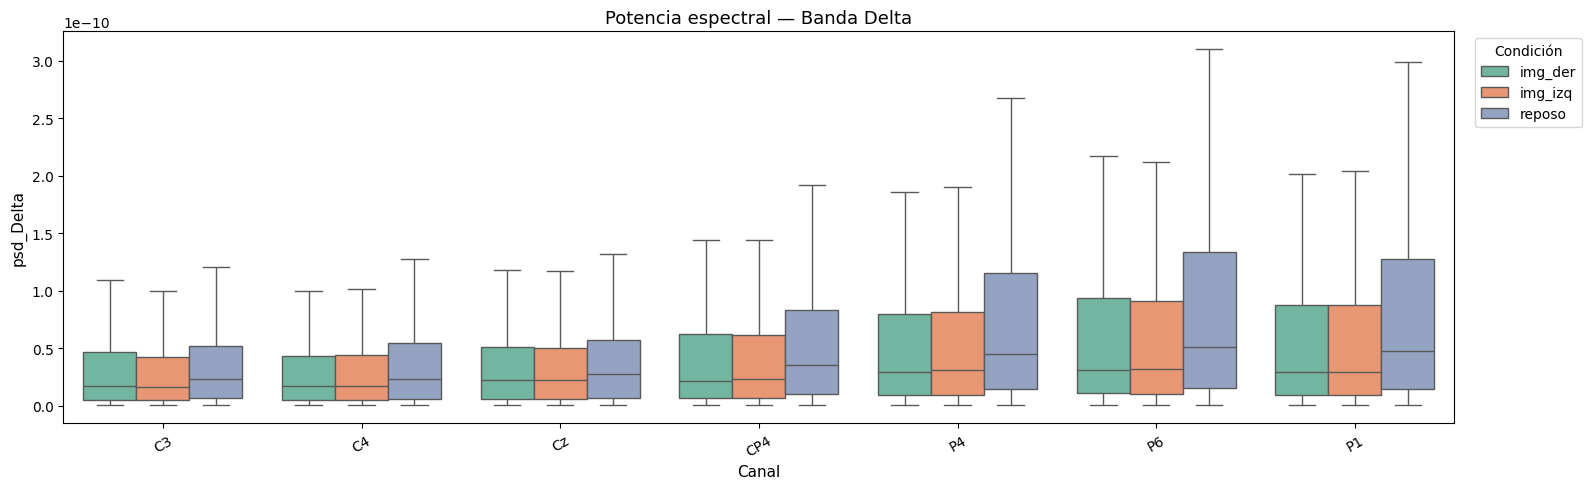

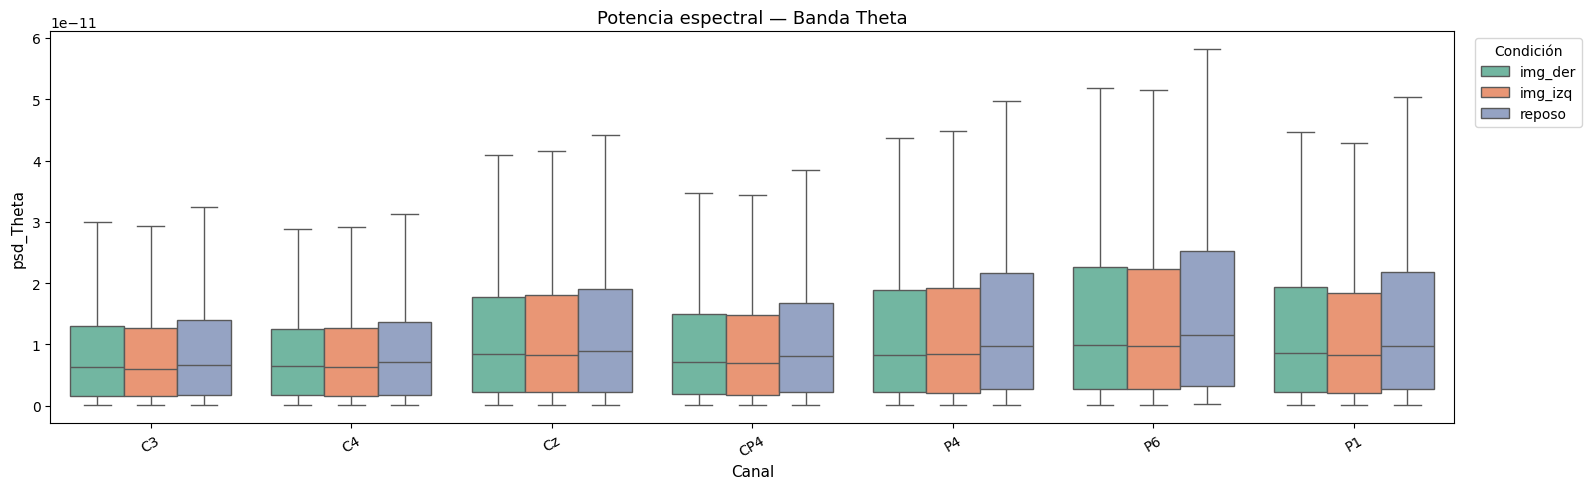

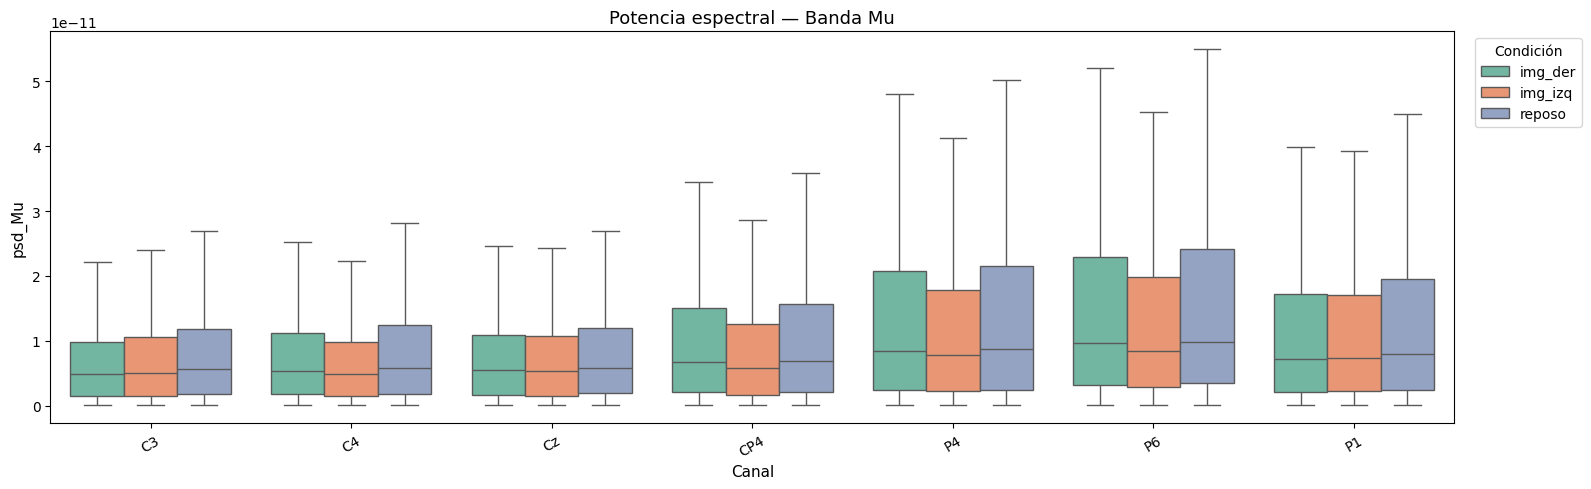

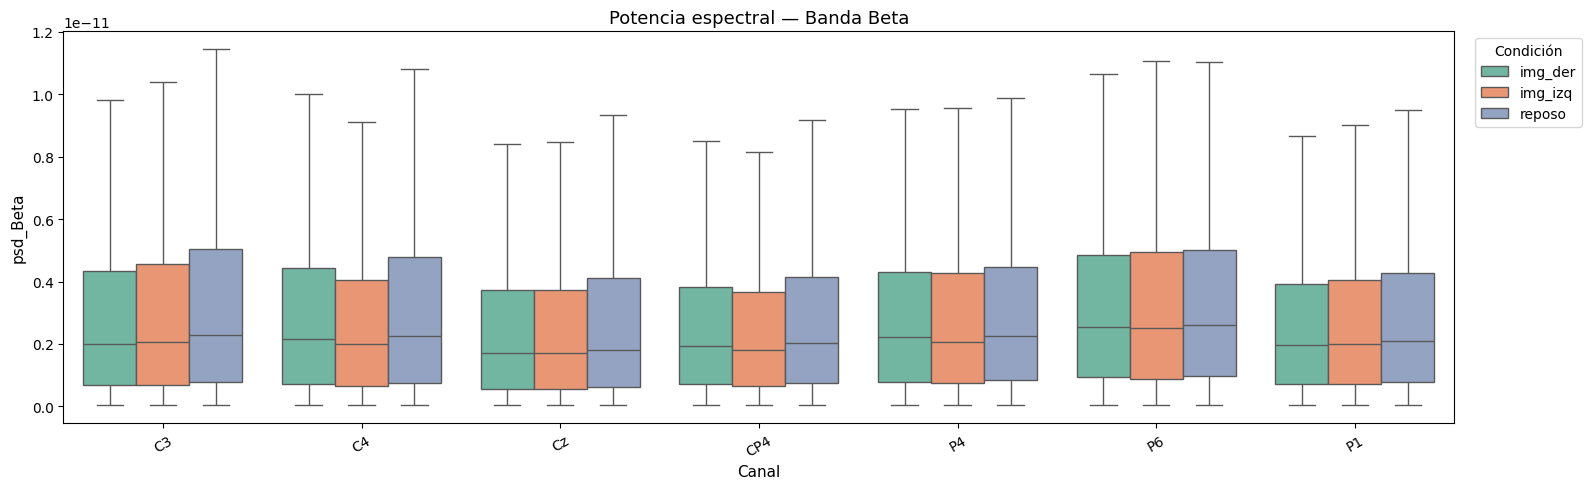

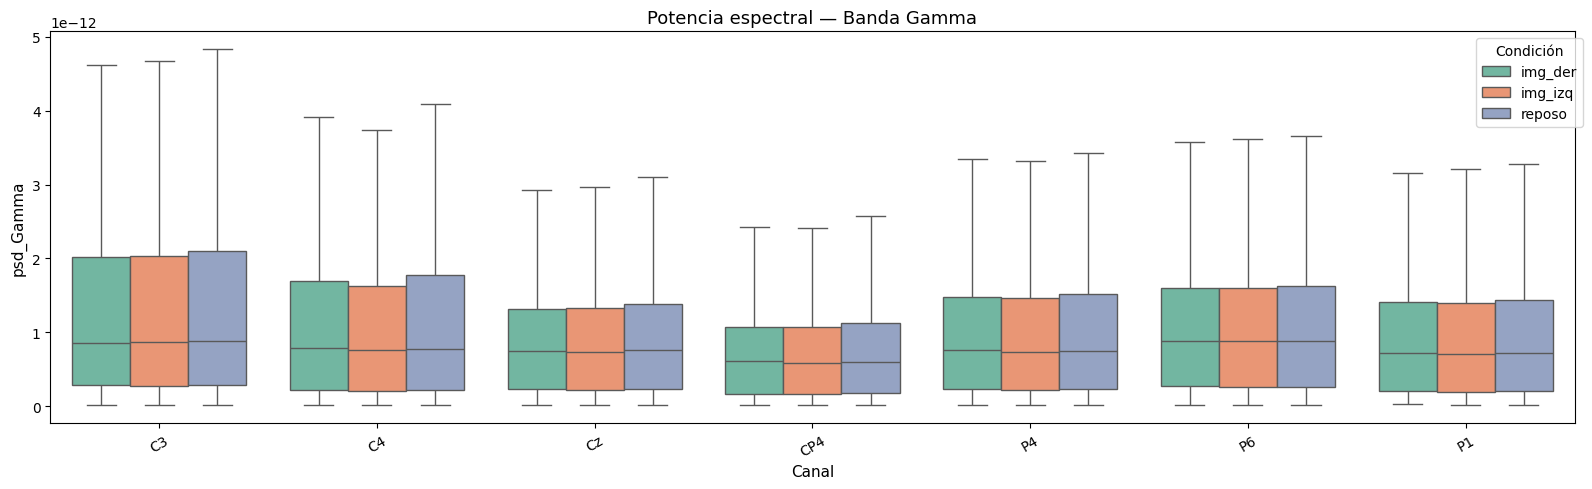

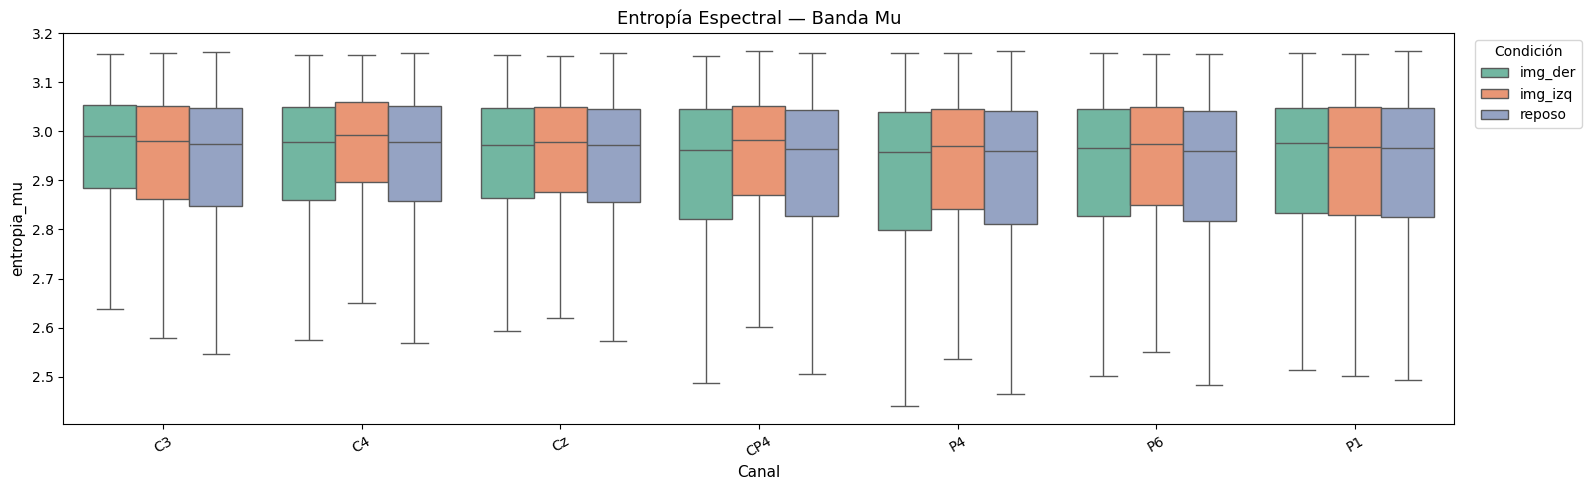

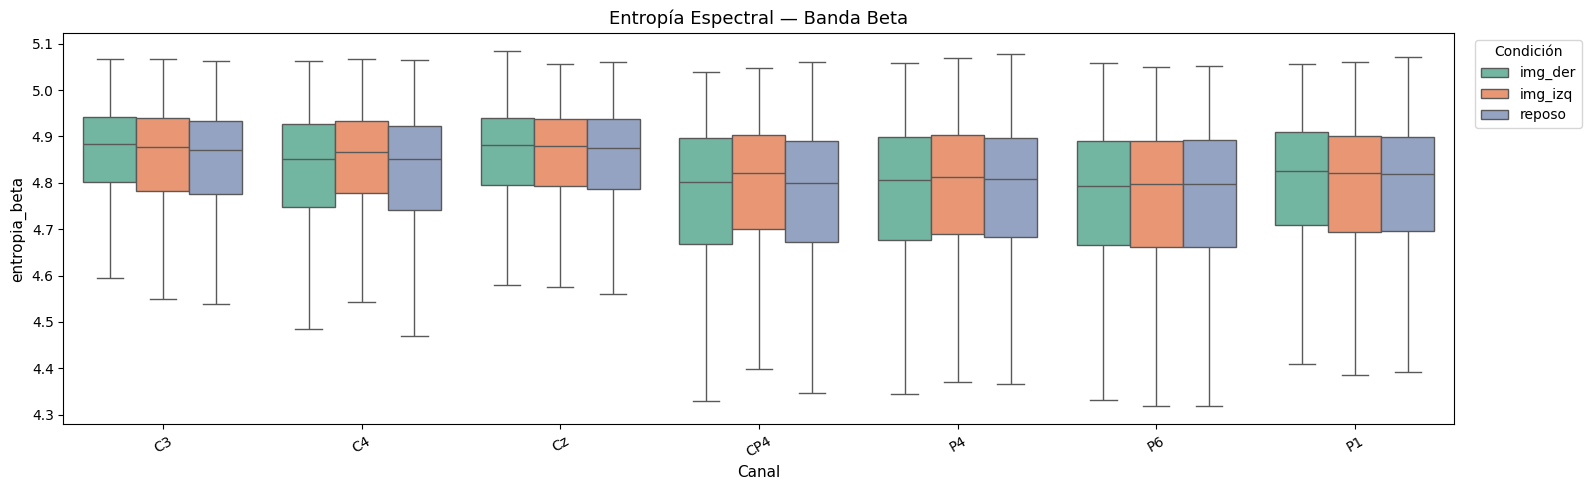

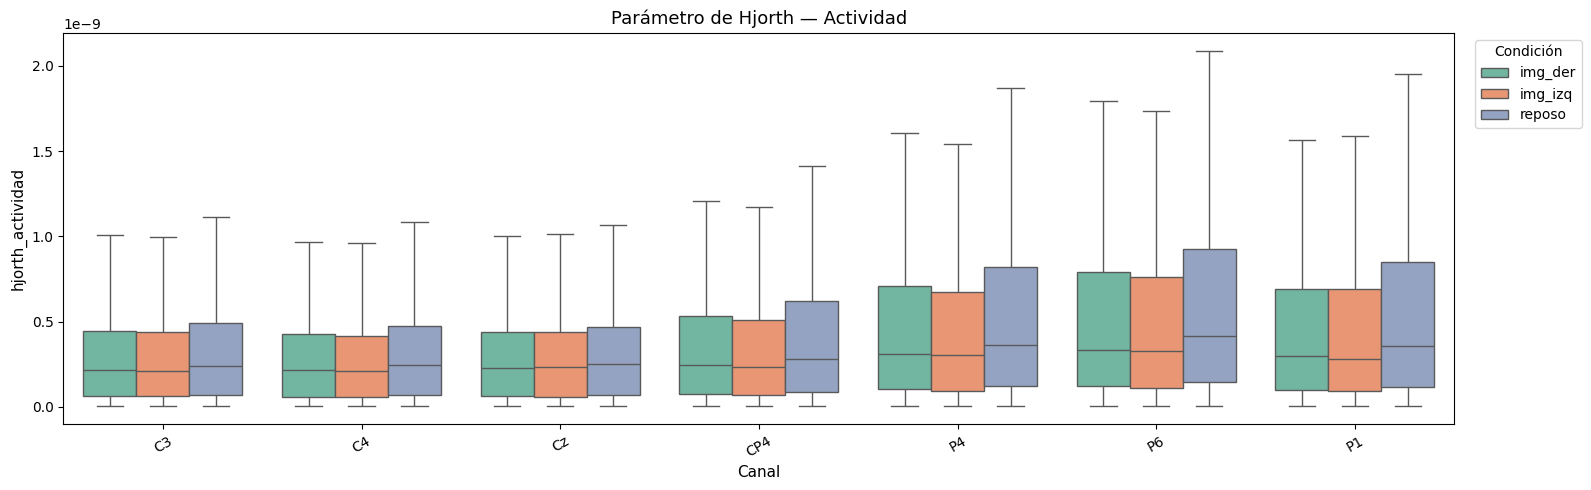

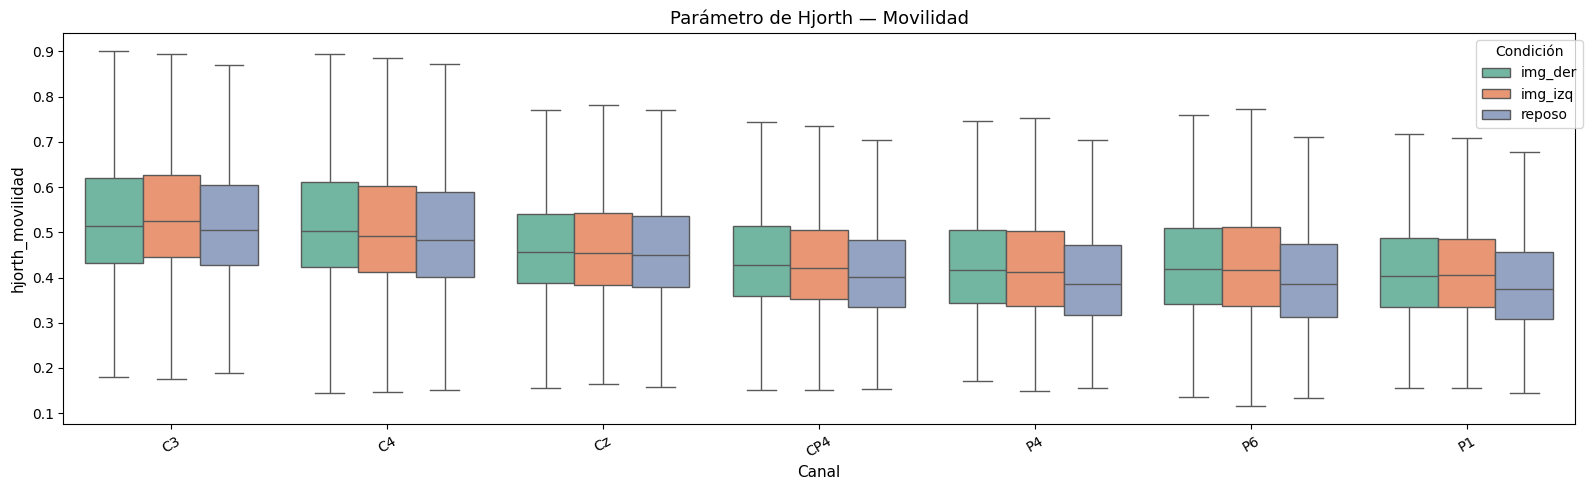

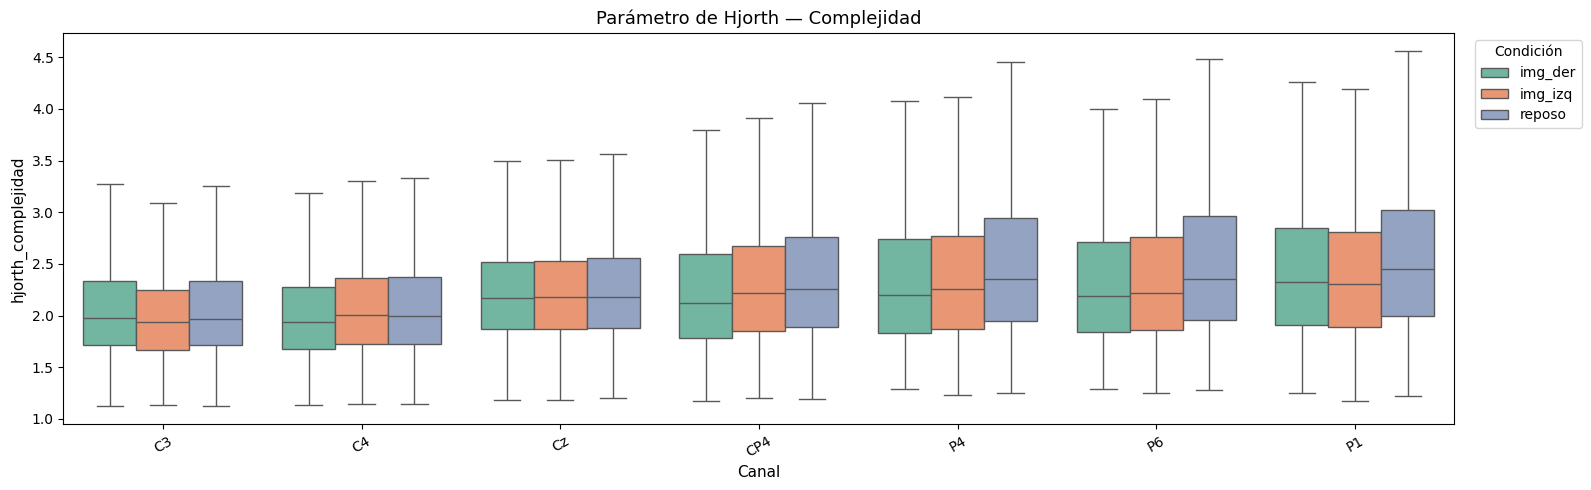

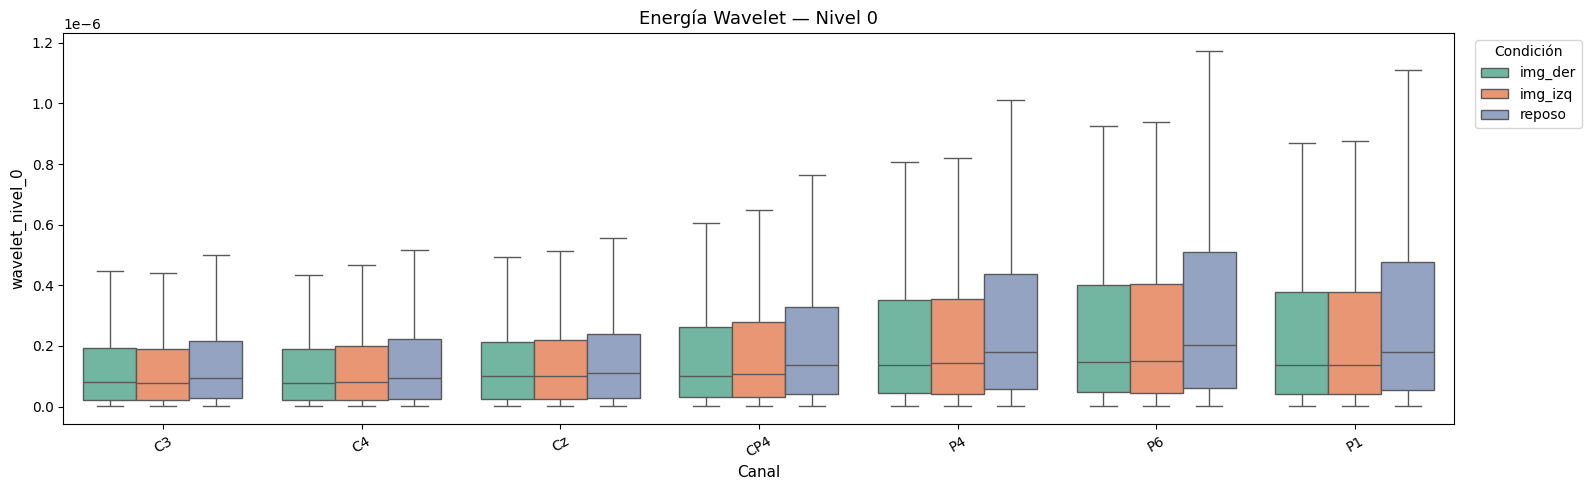

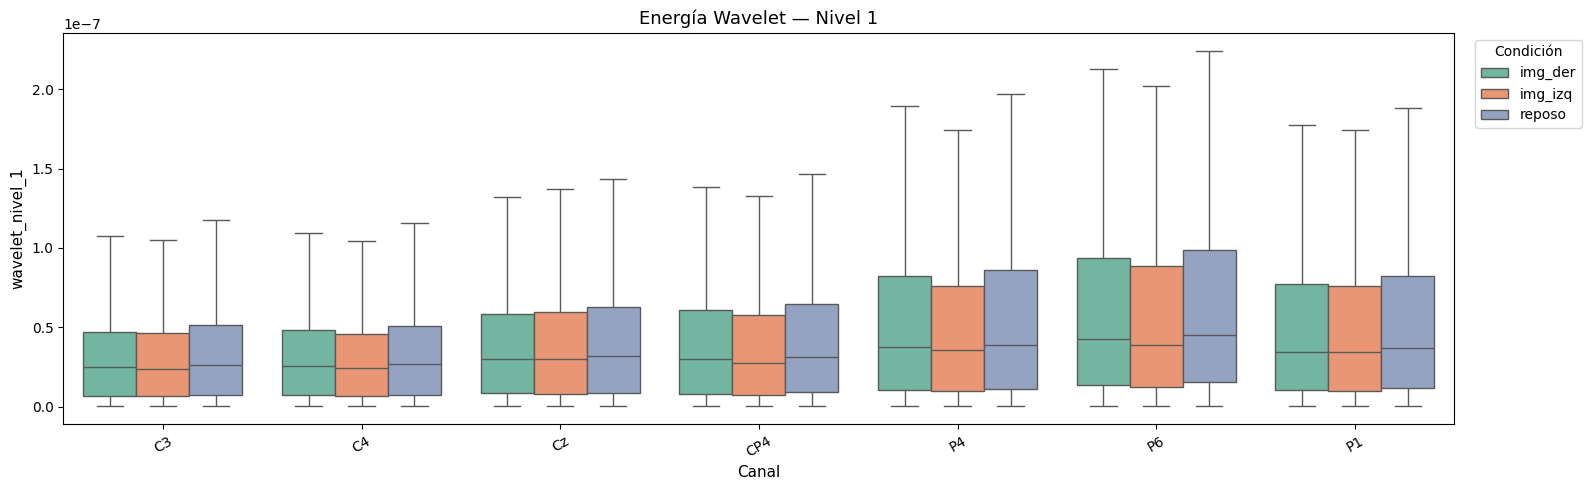

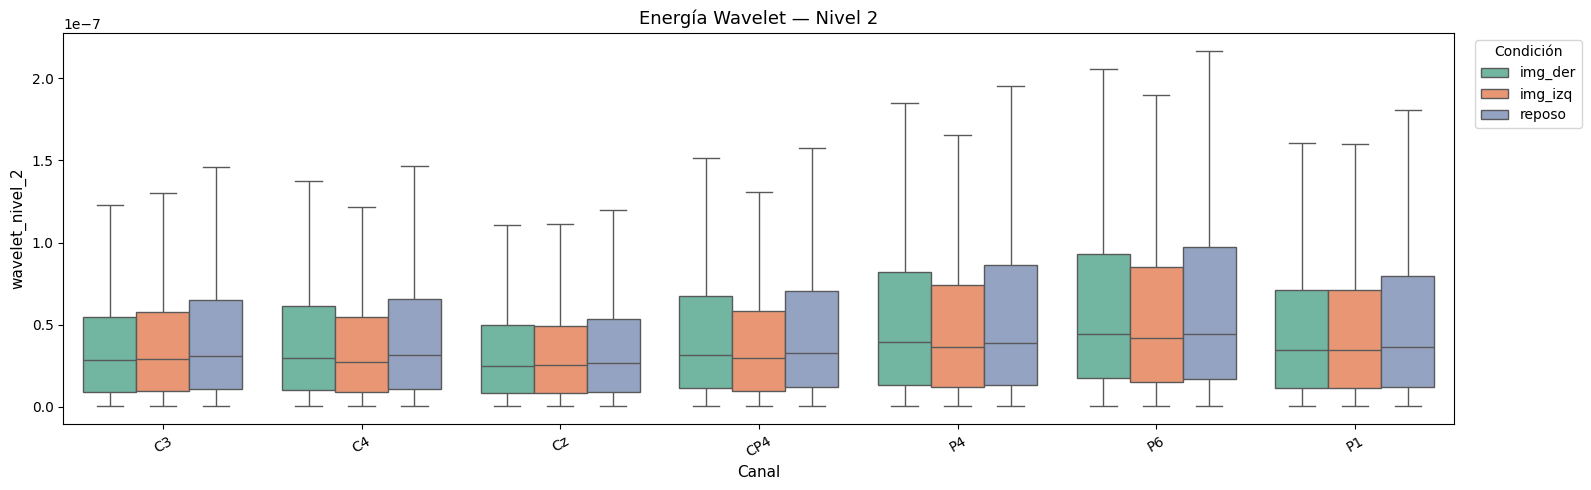

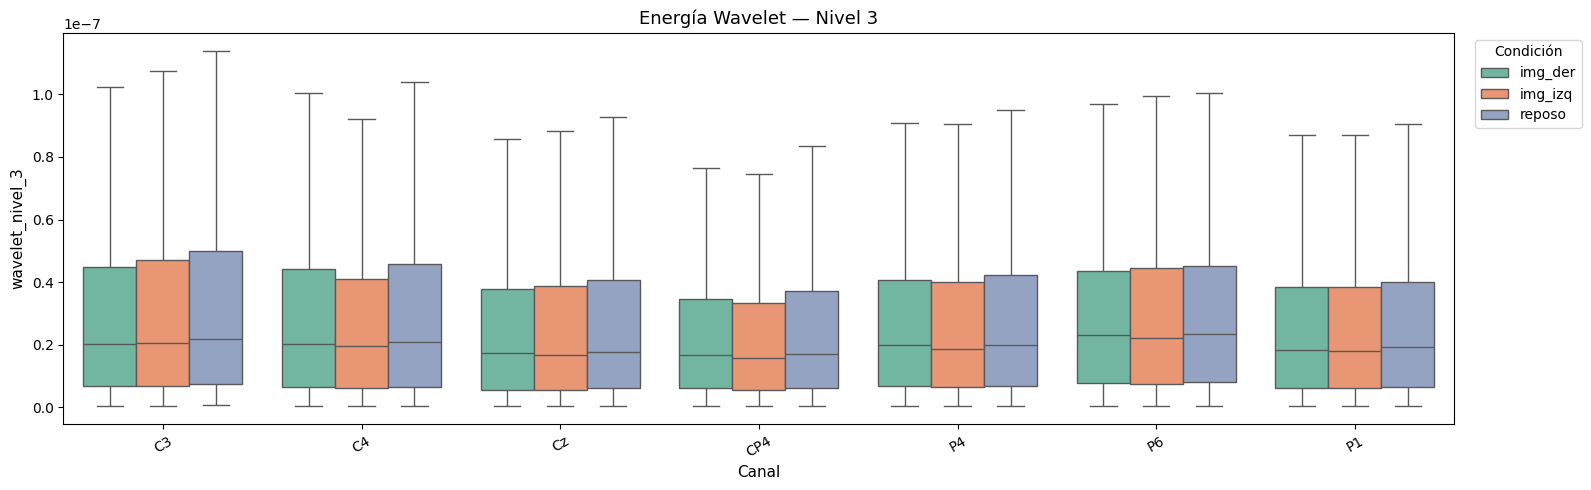

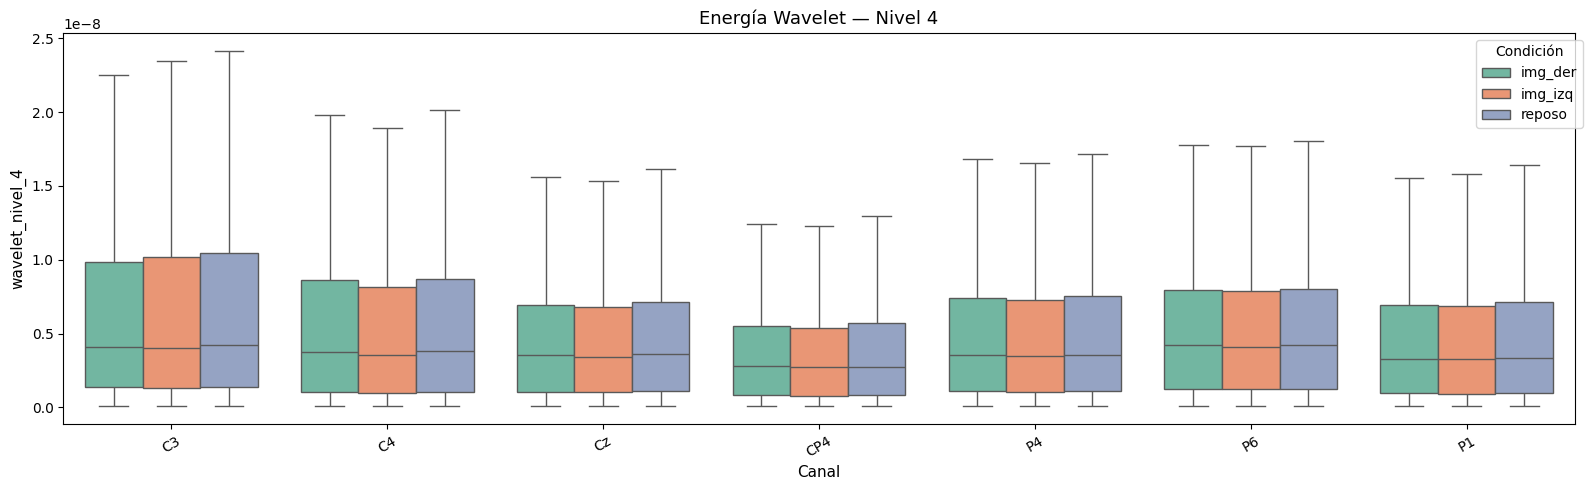

In [7]:
def graficar_indice(df, indice, titulo=None):
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.boxplot(data=df, x='canal', y=indice, hue='condicion',
                ax=ax, palette='Set2', showfliers=False)
    ax.set_title(titulo or f'Distribución de {indice} por canal y condición', fontsize=13)
    ax.set_xlabel('Canal', fontsize=11)
    ax.set_ylabel(indice, fontsize=11)
    ax.legend(title='Condición', bbox_to_anchor=(1.01, 1))
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

# Graficar todos los índices
for banda in ['psd_Delta', 'psd_Theta', 'psd_Mu', 'psd_Beta', 'psd_Gamma']:
    graficar_indice(df_caracteristicas, banda, f'Potencia espectral — Banda {banda.replace("psd_", "")}')

graficar_indice(df_caracteristicas, 'entropia_mu', 'Entropía Espectral — Banda Mu')
graficar_indice(df_caracteristicas, 'entropia_beta', 'Entropía Espectral — Banda Beta')

for hjorth in ['hjorth_actividad', 'hjorth_movilidad', 'hjorth_complejidad']:
    graficar_indice(df_caracteristicas, hjorth, f'Parámetro de Hjorth — {hjorth.replace("hjorth_", "").capitalize()}')

for nivel in range(5):
    graficar_indice(df_caracteristicas, f'wavelet_nivel_{nivel}', f'Energía Wavelet — Nivel {nivel}')

=== Top 10 combinaciones canal-índice más discriminativas ===

canal             indice  varianza
   P6 hjorth_complejidad  0.009340
   P1 hjorth_complejidad  0.008206
   P4 hjorth_complejidad  0.007581
  CP4 hjorth_complejidad  0.004533
   C4 hjorth_complejidad  0.001655
   C3 hjorth_complejidad  0.001180
  CP4        entropia_mu  0.000322
   P6   hjorth_movilidad  0.000314
   C4        entropia_mu  0.000278
   C3        entropia_mu  0.000270


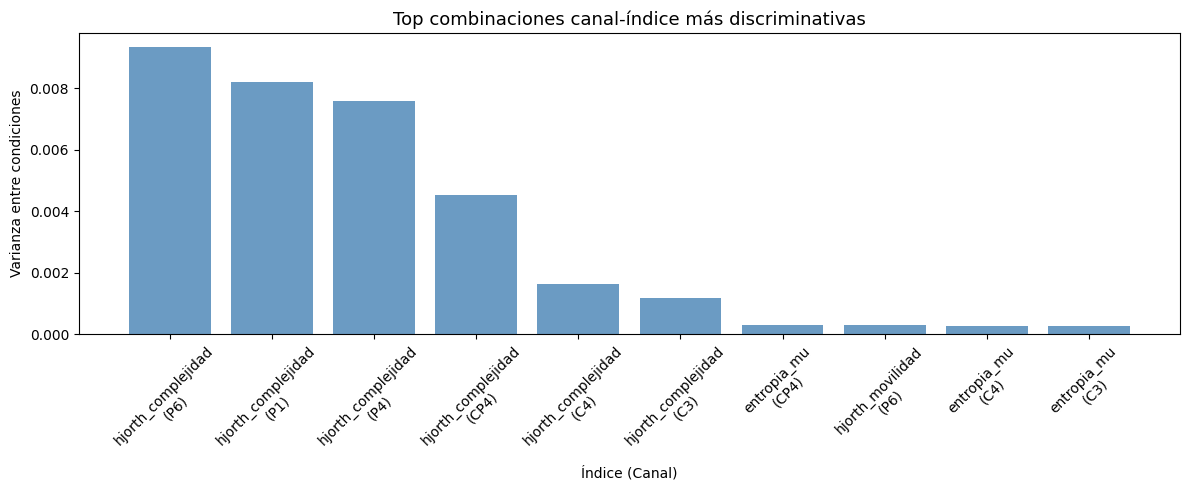


Índices seleccionados para clasificación: ['hjorth_complejidad', 'entropia_mu', 'hjorth_movilidad', 'entropia_beta']


In [8]:
def identificar_indices_por_canal(df, top_n=10):
    """
    Identifica las combinaciones índice-canal más discriminativas
    calculando la varianza entre condiciones por cada canal de forma
    independiente, evitando el enmascaramiento que ocurre al promediar
    sobre todos los canales.
    """
    indices = ['psd_Delta', 'psd_Theta', 'psd_Mu', 'psd_Beta', 'psd_Gamma',
               'entropia_mu', 'entropia_beta',
               'hjorth_actividad', 'hjorth_movilidad', 'hjorth_complejidad',
               'wavelet_nivel_0', 'wavelet_nivel_1', 'wavelet_nivel_2',
               'wavelet_nivel_3', 'wavelet_nivel_4']

    resultados = []
    for canal in df['canal'].unique():
        df_canal = df[df['canal'] == canal]
        for indice in indices:
            pivot    = df_canal.groupby('condicion')[indice].mean()
            varianza = pivot.var()
            resultados.append({
                'canal':    canal,
                'indice':   indice,
                'varianza': varianza
            })

    df_res = pd.DataFrame(resultados).sort_values('varianza', ascending=False)

    print(f"=== Top {top_n} combinaciones canal-índice más discriminativas ===\n")
    print(df_res.head(top_n).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 5))
    etiquetas = [f"{r['indice']}\n({r['canal']})" 
                 for _, r in df_res.head(top_n).iterrows()]
    ax.bar(etiquetas, df_res.head(top_n)['varianza'],
           color='steelblue', alpha=0.8)
    ax.set_title('Top combinaciones canal-índice más discriminativas', fontsize=13)
    ax.set_xlabel('Índice (Canal)')
    ax.set_ylabel('Varianza entre condiciones')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    return df_res.head(top_n)

# Ejecutar
df_relevantes = identificar_indices_por_canal(df_caracteristicas, top_n=10)

# Índices seleccionados para clasificación
indices_relevantes = [
    'hjorth_complejidad',
    'entropia_mu',
    'hjorth_movilidad',
    'entropia_beta'
]
print(f"\nÍndices seleccionados para clasificación: {indices_relevantes}")

### b. Pruebas de Hipótesis

Con base en el análisis descriptivo, se identificaron como índices más discriminativos: hjorth_complejidad, entropia_mu, hjorth_movilidad y entropia_beta. Se procede a verificar estadísticamente si las diferencias observadas entre las tres condiciones son significativas.

**Hipótesis evaluadas para cada índice y canal:**
- **H₀:** No existe diferencia en el índice entre las tres condiciones  (reposo, img_der, img_izq)
- **H₁:** Al menos una condición presenta un valor significativamente  diferente respecto a las demás

**Criterio de decisión:** p-valor < 0.05 → se rechaza H₀

Primero se evalúa la normalidad de los datos mediante Shapiro-Wilk para determinar si se aplica ANOVA (paramétrica) o Kruskal-Wallis (no paramétrica).

In [14]:
from scipy.stats import shapiro, f_oneway, kruskal
from itertools import combinations


# PRUEBAS DE HIPÓTESIS


def pruebas_hipotesis(df, indices, canales):
    """
    Aplica Shapiro-Wilk y según resultado ANOVA o Kruskal-Wallis
    por índice y canal.

    Parámetros:
        df (pd.DataFrame): DataFrame de características
        indices (list): índices a evaluar
        canales (list): canales a evaluar

    Retorna:
        pd.DataFrame: resultados de las pruebas
    """
    condiciones = df['condicion'].unique()
    resultados  = []

    for indice in indices:
        for canal in canales:
            df_canal = df[df['canal'] == canal]

            # Grupos por condición
            grupos = [
                df_canal[df_canal['condicion'] == cond][indice].dropna().values
                for cond in condiciones
            ]
            grupos_validos = [g for g in grupos if len(g) > 2]
            conds_validas  = [c for c, g in zip(condiciones, grupos) 
                              if len(g) > 2]

            if len(grupos_validos) < 2:
                continue

            # Shapiro-Wilk por grupo
            normales = []
            for g in grupos_validos:
                _, p = shapiro(g[:500] if len(g) > 500 else g)
                normales.append(p > 0.05)

            pct_normal = sum(normales) / len(normales)
            es_normal  = pct_normal >= 0.5

            # ANOVA o Kruskal-Wallis
            if es_normal:
                stat, p_val = f_oneway(*grupos_validos)
                prueba = 'ANOVA'
            else:
                stat, p_val = kruskal(*grupos_validos)
                prueba = 'Kruskal-Wallis'

            fila = {
                'indice':        indice,
                'canal':         canal,
                'prueba':        prueba,
                'estadistico':   round(stat, 4),
                'p_valor':       round(p_val, 6),
                'significativo': p_val < 0.05
            }

            # Post-hoc si es significativo
            if p_val < 0.05:
                n_comp = len(list(combinations(conds_validas, 2)))
                for c1, c2 in combinations(range(len(conds_validas)), 2):
                    g1, g2   = grupos_validos[c1], grupos_validos[c2]
                    _, p_par = kruskal(g1, g2)
                    p_corr   = min(p_par * n_comp, 1.0)
                    fila[f'{conds_validas[c1]}_vs_{conds_validas[c2]}'] = round(p_corr, 4)

            resultados.append(fila)

    df_res = pd.DataFrame(resultados)
    sig    = df_res[df_res['significativo'] == True]

    print(f"\nCanales e índices con diferencias significativas: "
          f"{len(sig)} de {len(df_res)}")
    print(sig[['indice', 'canal', 'prueba', 'estadistico', 'p_valor']]
          .to_string(index=False))

    return df_res


# Canales de interés
canales_interes = ['C3', 'C4', 'Cz', 'CP4', 'P4', 'P6', 'P1']

# Ejecutar pruebas
df_hipotesis = pruebas_hipotesis(
    df_caracteristicas,
    indices_relevantes,
    canales_interes
)


Canales e índices con diferencias significativas: 23 de 28
            indice canal         prueba  estadistico  p_valor
hjorth_complejidad    C3 Kruskal-Wallis      23.1105 0.000010
hjorth_complejidad    C4 Kruskal-Wallis      35.4050 0.000000
hjorth_complejidad   CP4 Kruskal-Wallis      77.2413 0.000000
hjorth_complejidad    P4 Kruskal-Wallis     100.3241 0.000000
hjorth_complejidad    P6 Kruskal-Wallis     119.6735 0.000000
hjorth_complejidad    P1 Kruskal-Wallis     101.4901 0.000000
  hjorth_movilidad    C3 Kruskal-Wallis      29.5907 0.000000
  hjorth_movilidad    C4 Kruskal-Wallis      38.5491 0.000000
  hjorth_movilidad    Cz Kruskal-Wallis       6.4318 0.040119
  hjorth_movilidad   CP4 Kruskal-Wallis      99.1250 0.000000
  hjorth_movilidad    P4 Kruskal-Wallis     128.8826 0.000000
  hjorth_movilidad    P6 Kruskal-Wallis     150.2503 0.000000
  hjorth_movilidad    P1 Kruskal-Wallis     144.8179 0.000000
       entropia_mu    C3 Kruskal-Wallis      27.7802 0.000001
       ent

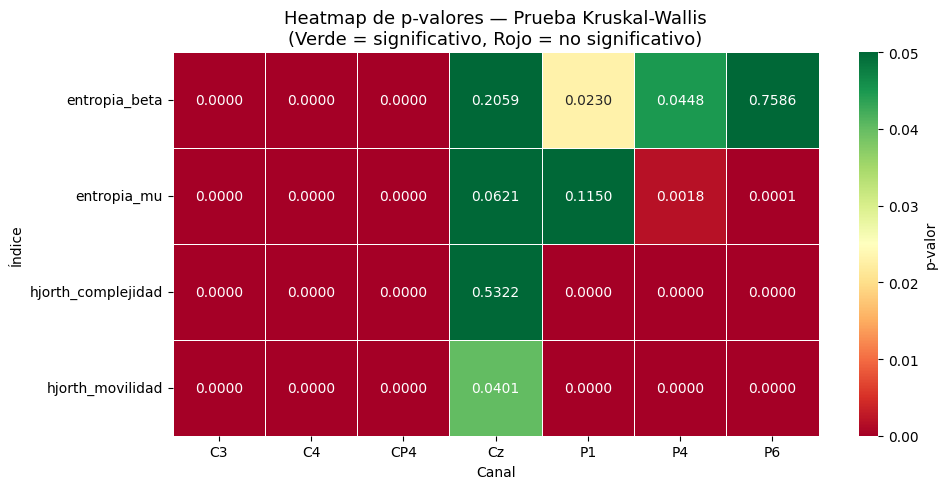

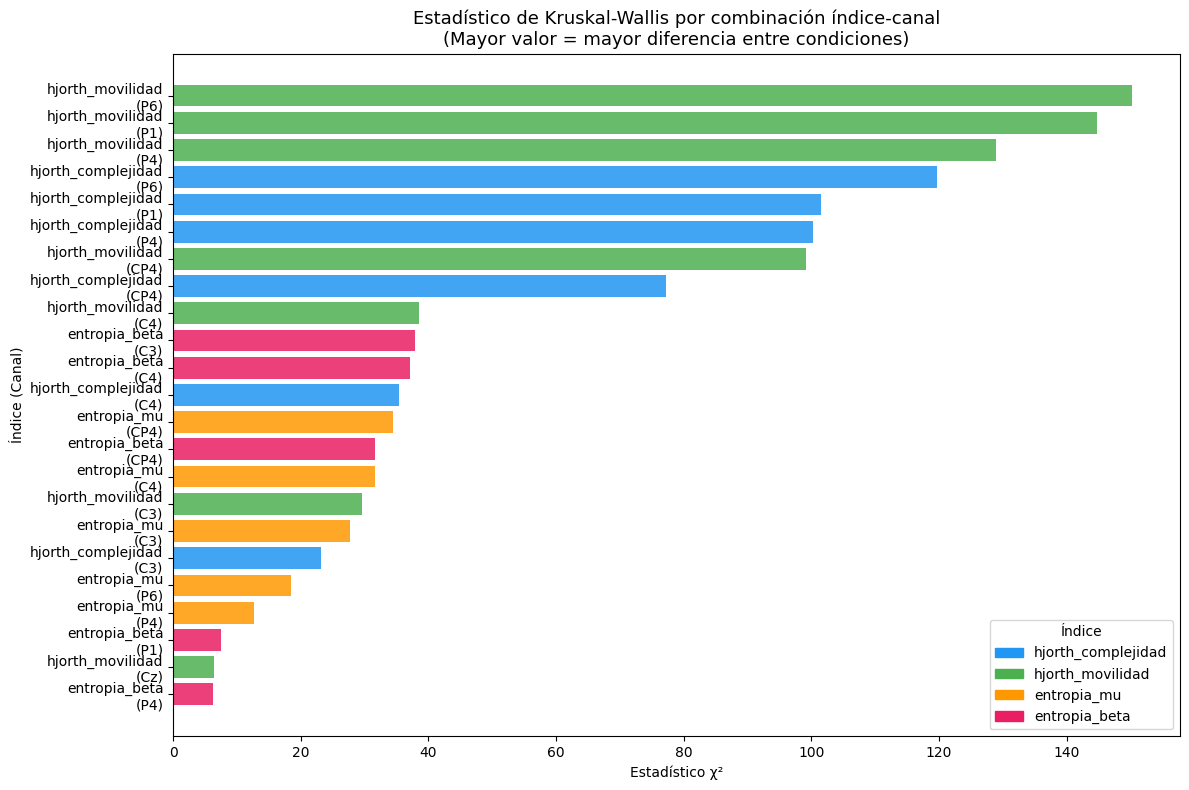

In [15]:
def graficar_hipotesis(df_hipotesis):
    """
    Grafica los resultados de las pruebas de hipótesis como heatmap
    y gráfica de estadísticos.
    """
    # Filtrar solo significativos
    df_sig = df_hipotesis[df_hipotesis['significativo'] == True].copy()

    # ── Gráfica 1: Heatmap de p-valores ──
    pivot_p = df_hipotesis.pivot(index='indice', columns='canal', values='p_valor')

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        pivot_p,
        annot=True,
        fmt='.4f',
        cmap='RdYlGn',
        linewidths=0.5,
        ax=ax,
        vmin=0,
        vmax=0.05,
        cbar_kws={'label': 'p-valor'}
    )
    ax.set_title('Heatmap de p-valores — Prueba Kruskal-Wallis\n'
                 '(Verde = significativo, Rojo = no significativo)',
                 fontsize=13)
    ax.set_xlabel('Canal')
    ax.set_ylabel('Índice')
    plt.tight_layout()
    plt.show()

    # ── Gráfica 2: Estadístico por combinación índice-canal ──
    df_sig['etiqueta'] = df_sig['indice'] + '\n(' + df_sig['canal'] + ')'
    df_sig = df_sig.sort_values('estadistico', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 8))
    colores = {
        'hjorth_complejidad': '#2196F3',
        'hjorth_movilidad':   '#4CAF50',
        'entropia_mu':        '#FF9800',
        'entropia_beta':      '#E91E63'
    }
    bars = ax.barh(
        df_sig['etiqueta'],
        df_sig['estadistico'],
        color=[colores.get(i, 'gray') for i in df_sig['indice']],
        alpha=0.85
    )
    ax.set_title('Estadístico de Kruskal-Wallis por combinación índice-canal\n'
                 '(Mayor valor = mayor diferencia entre condiciones)',
                 fontsize=13)
    ax.set_xlabel('Estadístico χ²')
    ax.set_ylabel('Índice (Canal)')

    # Leyenda
    from matplotlib.patches import Patch
    leyenda = [Patch(color=c, label=i) for i, c in colores.items()]
    ax.legend(handles=leyenda, title='Índice', loc='lower right')

    plt.tight_layout()
    plt.show()

# Ejecutar
graficar_hipotesis(df_hipotesis)

In [20]:
# Verificación de valores reportados en el análisis
print("=== Verificación de valores reportados ===\n")
sig = df_hipotesis[df_hipotesis['significativo'] == True]
print(f"Total combinaciones significativas: {len(sig)} de {len(df_hipotesis)}\n")
print("Top 5 por estadístico:")
for _, row in sig.sort_values('estadistico', ascending=False).head(5).iterrows():
    print(f"  {row['indice']} en {row['canal']}: χ² = {row['estadistico']:.2f}, p = {row['p_valor']:.6f}")

=== Verificación de valores reportados ===

Total combinaciones significativas: 23 de 28

Top 5 por estadístico:
  hjorth_movilidad en P6: χ² = 150.25, p = 0.000000
  hjorth_movilidad en P1: χ² = 144.82, p = 0.000000
  hjorth_movilidad en P4: χ² = 128.88, p = 0.000000
  hjorth_complejidad en P6: χ² = 119.67, p = 0.000000
  hjorth_complejidad en P1: χ² = 101.49, p = 0.000000


### Visualización de resultados — Pruebas de hipótesis

#### Heatmap de p-valores

El heatmap permite visualizar de forma simultánea los resultados de todas 
las pruebas de Kruskal-Wallis realizadas. Cada celda representa una 
combinación índice-canal, donde el color indica el p-valor obtenido:
las celdas en verde corresponden a combinaciones con diferencias 
estadísticamente significativas (p < 0.05), mientras que las celdas 
en rojo indican ausencia de significancia.

De los resultados se observa que:

- Los canales **C3, C4 y CP4** presentan significancia en **todos** los 
  índices evaluados, confirmando su relevancia para discriminar entre 
  las tres condiciones experimentales.
- El canal **Cz** muestra significancia únicamente en hjorth_movilidad 
  (p = 0.040), siendo el canal con menor poder discriminativo del conjunto.
- Los canales **parietales (P1, P4, P6)** presentan significancia en la 
  mayoría de los índices, especialmente en hjorth_complejidad y 
  hjorth_movilidad, lo cual es consistente con los resultados del 
  proyecto 1 donde estos canales mostraron mayor varianza entre condiciones.
- La combinación **hjorth_complejidad en Cz** (p = 0.532) y 
  **entropia_beta en P6** (p = 0.759) son las únicas combinaciones 
  que no alcanzan significancia estadística.

---

#### Estadístico de Kruskal-Wallis por combinación índice-canal

La gráfica de barras horizontales muestra el valor del estadístico χ² 
para cada combinación significativa, ordenado de mayor a menor. Un valor 
más alto indica una diferencia más pronunciada entre las tres condiciones 
experimentales.

Los principales hallazgos son:

- **hjorth_movilidad en P6** (χ² = 150.25) y **hjorth_movilidad en P1** 
(χ² = 144.82) son las combinaciones con mayor poder discriminativo de todo el análisis, superando ampliamente al resto.

- **hjorth_movilidad** domina las primeras posiciones en los canales parietales (P6, P1, P4), lo que indica que la frecuencia media de la señal EEG es la característica que más cambia entre condiciones en estas regiones.

- **hjorth_complejidad** ocupa las posiciones intermedias-altas, con mayor estadístico en los canales parietales que en los motores clásicos.

- Los índices de **entropía** (mu y beta) presentan estadísticos más bajos pero consistentemente significativos en los canales motores C3, C4 y CP4, aportando información complementaria a los parámetros de Hjorth.

- Los canales **C3 y C4** aparecen en posiciones más bajas del ranking pero con valores significativos en todos los índices, confirmando que los electrodos motores clásicos sí capturan diferencias entre condiciones aunque con menor magnitud que los canales parietales.

En conjunto, estos resultados confirman que los cuatro índices seleccionados — hjorth_complejidad, hjorth_movilidad, entropia_mu y entropia_beta — tienen poder discriminativo estadísticamente demostrado para las tres condiciones experimentales, validando su uso como características de entrada para los clasificadores BCI de la siguiente sección.

---


---
### Resultados de las pruebas de hipótesis

#### Selección de la prueba estadística

La prueba de Shapiro-Wilk indicó que la mayoría de los grupos no siguen una distribución normal, por lo que se aplicó la prueba no paramétrica de **Kruskal-Wallis** para comparar las tres condiciones experimentales en cada combinación índice-canal. Cuando el resultado fue significativo (p < 0.05), se aplicó un análisis post-hoc con corrección de Bonferroni para identificar qué pares de condiciones difieren.

---

#### Resultados generales

Según los resultados impresos en la celda de verificación anterior, se encontraron diferencias estadísticamente significativas en **23 de 28 combinaciones** índice-canal evaluadas (82.1%), lo que confirma que los índices seleccionados tienen poder discriminativo real entre las tres condiciones experimentales.

---

#### Resultados por índice

**hjorth_complejidad** — significativo en 6 de 7 canales:
- Mayor estadístico en P6 (χ² = 119.67) y P1 (χ² = 101.49)
- Confirma que la complejidad de la señal EEG cambia significativamente entre reposo e imaginación de movimiento en todos los canales motores y parietales analizados.

**hjorth_movilidad** — significativo en 7 de 7 canales:
- Mayor estadístico en P6 (χ² = 150.25) y P1 (χ² = 144.82)
- Es el único índice significativo en **todos** los canales incluyendo Cz.
- Indica que la frecuencia media de la señal EEG varía consistentemente entre condiciones en toda la región motora y parietal.

**entropia_mu** — significativo en 5 de 7 canales:
- Mayor estadístico en CP4 (χ² = 34.49) y C4 (χ² = 31.66)
- Refleja cambios en la complejidad espectral en la banda Mu durante la imaginación de movimiento, especialmente en el hemisferio derecho.

**entropia_beta** — significativo en 5 de 7 canales:
- Mayor estadístico en C3 (χ² = 37.86) y C4 (χ² = 37.07)
- Muestra diferencias en la complejidad espectral de la banda Beta principalmente en los canales motores clásicos.

---

#### Conclusión
Se rechaza H₀ en 23 de 28 combinaciones evaluadas, confirmando que los cuatro índices seleccionados — hjorth_complejidad, hjorth_movilidad, entropia_mu y entropia_beta — presentan diferencias estadísticamente significativas entre las condiciones de reposo, imaginación de mano derecha e imaginación de mano izquierda. Estos índices serán utilizados como características de entrada para los clasificadores BCI desarrollados en la siguiente sección.


---

## Clasificación

### Introducción

Con base en los resultados del análisis estadístico, se confirmó que los 
cuatro índices seleccionados — hjorth_complejidad, hjorth_movilidad, 
entropia_mu y entropia_beta — presentan diferencias estadísticamente 
significativas entre las tres condiciones experimentales en la mayoría 
de los canales evaluados. Estos índices serán utilizados como 
características de entrada para construir clasificadores BCI capaces 
de distinguir entre reposo, imaginación de mano derecha e imaginación 
de mano izquierda.

El proceso de clasificación se desarrolla en las siguientes etapas:

1. **Preparación de datos:** transformación del DataFrame al formato 
   requerido por los clasificadores, donde cada fila representa una 
   época completa con sus 28 características (7 canales × 4 índices).

2. **Estrategia de entrenamiento:** validación cruzada K-fold (k=5) 
   para garantizar una evaluación robusta y evitar el sobreajuste.

3. **Clasificadores implementados:**
   - Tres arquitecturas de red neuronal
   - Máquina de Soporte Vectorial (SVM)
   - Extreme Gradient Boosting (XGBoost)

4. **Evaluación:** matrices de confusión y métricas de desempeño 
   (accuracy, precision, recall, F1-score) para cada clasificador.

---

### Paso 1 — Preparación de datos para clasificación

Antes de entrenar los clasificadores, se transforma el DataFrame de 
formato largo (una fila por época-canal) a formato ancho (una fila por 
época), donde cada característica de cada canal queda como una columna 
independiente. Esto genera un vector de 28 características por época 
que constituye la entrada de los clasificadores.

In [10]:

# CLASIFICACIÓN — PREPARACIÓN DE DATOS


# Índices y canales seleccionados
indices_relevantes  = ['hjorth_complejidad', 'hjorth_movilidad',
                       'entropia_mu', 'entropia_beta']
canales_interes     = ['C3', 'C4', 'Cz', 'CP4', 'P4', 'P6', 'P1']

# Filtrar solo índices y canales relevantes
df_filtrado = df_caracteristicas[
    df_caracteristicas['canal'].isin(canales_interes)
][['sujeto', 'condicion', 'canal', 'epoca', 'label'] + indices_relevantes].copy()

# Pivot: una fila por época con todos los canales como columnas
df_pivot = df_filtrado.pivot_table(
    index=['sujeto', 'condicion', 'epoca', 'label'],
    columns='canal',
    values=indices_relevantes
)

# Aplanar nombres de columnas
df_pivot.columns = [f'{indice}_{canal}' 
                    for indice, canal in df_pivot.columns]
df_pivot = df_pivot.reset_index()

print(f"DataFrame para ML:")
print(f"  Filas:        {len(df_pivot)}")
print(f"  Características: {len([c for c in df_pivot.columns if c not in ['sujeto', 'condicion', 'epoca', 'label']])}")
print(f"  Columnas:     {list(df_pivot.columns[:8])} ...")
df_pivot.head()

DataFrame para ML:
  Filas:        9720
  Características: 28
  Columnas:     ['sujeto', 'condicion', 'epoca', 'label', 'entropia_beta_C3', 'entropia_beta_C4', 'entropia_beta_CP4', 'entropia_beta_Cz'] ...


,sujeto,condicion,epoca,label,entropia_beta_C3,entropia_beta_C4,entropia_beta_CP4,entropia_beta_Cz,entropia_beta_P1,entropia_beta_P4,...,hjorth_complejidad_P1,hjorth_complejidad_P4,hjorth_complejidad_P6,hjorth_movilidad_C3,hjorth_movilidad_C4,hjorth_movilidad_CP4,hjorth_movilidad_Cz,hjorth_movilidad_P1,hjorth_movilidad_P4,hjorth_movilidad_P6
0,S001,img_der,0,1,4.984094,4.968915,4.726617,4.977057,4.824456,4.837895,...,2.510856,2.269555,2.225356,0.610487,0.480149,0.449716,0.470565,0.435259,0.488485,0.495568
1,S001,img_der,1,1,4.766762,4.961595,4.906215,4.965751,4.829186,4.920777,...,2.663266,2.195154,2.060402,0.524688,0.477075,0.396252,0.387492,0.386335,0.472825,0.504415
2,S001,img_der,2,1,4.858355,4.925328,4.808489,4.974963,4.909645,4.870925,...,2.712518,2.607256,2.370198,0.468169,0.532857,0.415064,0.414806,0.375894,0.409290,0.461330
3,S001,img_der,3,1,4.775165,4.695238,4.684575,4.762727,4.675308,4.814851,...,2.983904,2.495425,2.276236,0.453650,0.492811,0.401079,0.395490,0.312201,0.375521,0.416342
4,S001,img_der,4,1,4.756464,4.961365,4.887392,4.941033,4.769069,4.523434,...,2.706866,2.231712,2.076655,0.548497,0.473268,0.422184,0.381290,0.377772,0.443939,0.470849


### Paso 2 — Estrategia de entrenamiento: K-Fold Cross Validation

La validación cruzada K-Fold divide el conjunto de datos en k subconjuntos 
(folds) de igual tamaño. En cada iteración, k-1 folds se usan para 
entrenar el modelo y 1 fold se usa para evaluarlo. Este proceso se repite 
k veces, usando cada fold como conjunto de prueba exactamente una vez.

Se utiliza k=5, lo que significa que el 80% de los datos se usa para 
entrenamiento y el 20% para prueba en cada iteración. Esta estrategia 
garantiza que todos los datos participen tanto en entrenamiento como en 
evaluación, reduciendo el sesgo y la varianza de la estimación del 
rendimiento del modelo.

Para este proyecto se usa **Stratified K-Fold**, que garantiza que cada 
fold mantenga la misma proporción de clases (reposo, img_der, img_izq) 
que el conjunto original, evitando desbalances en la evaluación.

Justificación de k=5:
Se eligió k=5 como balance entre sesgo y varianza. Con k=3 el conjunto de entrenamiento sería solo el 67% de los datos, lo que puede afectar la convergencia de los MLPs. Con k=10 cada fold de prueba tendría muy pocas épocas, aumentando la varianza de la estimación. k=5 es además el valor más reportado en la literatura BCI, facilitando la comparación con otros trabajos.

Stratified vs. K-Fold regular:
Se usa StratifiedKFold en lugar de KFold estándar para garantizar que cada fold mantenga la misma proporción de clases (33%/33%/33% entre reposo, img_der e img_izq), evitando que algún fold quede desbalanceado durante la evaluación.

Limitación del enfoque:
El dataset mezcla épocas de 109 sujetos sin separación por sujeto (subject-independent), lo que significa que épocas del mismo sujeto pueden aparecer tanto en entrenamiento como en prueba, pudiendo inflar ligeramente el accuracy estimado. Para un sistema BCI real se recomendaría Leave-One-Subject-Out (LOSO), pero k=5 es adecuado para el alcance de este proyecto.

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np

# PREPARAR X e y


# Características y etiquetas
feature_cols = [c for c in df_pivot.columns 
                if c not in ['sujeto', 'condicion', 'epoca', 'label']]

X = df_pivot[feature_cols].values
y = df_pivot['label'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Distribución de clases:")
for label, nombre in zip([0, 1, 2], ['reposo', 'img_der', 'img_izq']):
    print(f"  {nombre} ({label}): {(y == label).sum()} épocas")

# ============================================================
# K-FOLD ESTRATIFICADO
# ============================================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nK-Fold configurado:")
print(f"  k = 5 folds")
print(f"  Entrenamiento: ~{int(len(X)*0.8)} épocas por fold")
print(f"  Prueba:        ~{int(len(X)*0.2)} épocas por fold")

# Verificar distribución por fold
for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    y_train = y[train_idx]
    y_test  = y[test_idx]
    print(f"\n  Fold {fold+1}:")
    print(f"    Train: {len(train_idx)} épocas | "
          f"reposo={( y_train==0).sum()} | "
          f"img_der={(y_train==1).sum()} | "
          f"img_izq={(y_train==2).sum()}")
    print(f"    Test:  {len(test_idx)} épocas  | "
          f"reposo={(y_test==0).sum()} | "
          f"img_der={(y_test==1).sum()} | "
          f"img_izq={(y_test==2).sum()}")

X shape: (9720, 28)
y shape: (9720,)
Distribución de clases:
  reposo (0): 4809 épocas
  img_der (1): 2433 épocas
  img_izq (2): 2478 épocas

K-Fold configurado:
  k = 5 folds
  Entrenamiento: ~7776 épocas por fold
  Prueba:        ~1944 épocas por fold

  Fold 1:
    Train: 7776 épocas | reposo=3848 | img_der=1946 | img_izq=1982
    Test:  1944 épocas  | reposo=961 | img_der=487 | img_izq=496

  Fold 2:
    Train: 7776 épocas | reposo=3847 | img_der=1946 | img_izq=1983
    Test:  1944 épocas  | reposo=962 | img_der=487 | img_izq=495

  Fold 3:
    Train: 7776 épocas | reposo=3847 | img_der=1946 | img_izq=1983
    Test:  1944 épocas  | reposo=962 | img_der=487 | img_izq=495

  Fold 4:
    Train: 7776 épocas | reposo=3847 | img_der=1947 | img_izq=1982
    Test:  1944 épocas  | reposo=962 | img_der=486 | img_izq=496

  Fold 5:
    Train: 7776 épocas | reposo=3847 | img_der=1947 | img_izq=1982
    Test:  1944 épocas  | reposo=962 | img_der=486 | img_izq=496


### Primera prueba — Dataset sin balancear (28 características)

Se realiza una primera evaluación de los clasificadores usando el dataset original sin balanceo de clases, con los 4 índices más discriminativos (28 características). Esta prueba inicial permite identificar el efecto del desbalance de clases en el rendimiento de los modelos.

Entradas: 28 | Salidas: 3
Regla 1 → neuronas ocultas entre 3 y 28
Regla 2 → neuronas ocultas ≈ 21
Regla 3 → neuronas ocultas < 56
SVM — Kernel RBF
  Fold 1: accuracy = 0.4342
  Fold 2: accuracy = 0.4342
  Fold 3: accuracy = 0.4239
  Fold 4: accuracy = 0.4578
  Fold 5: accuracy = 0.4372

SVM RBF:
  Accuracy promedio: 0.4374 ± 0.0111

              precision    recall  f1-score   support

      reposo       0.62      0.45      0.52      4809
     img_der       0.34      0.44      0.38      2433
     img_izq       0.34      0.42      0.37      2478

    accuracy                           0.44      9720
   macro avg       0.43      0.43      0.42      9720
weighted avg       0.48      0.44      0.45      9720



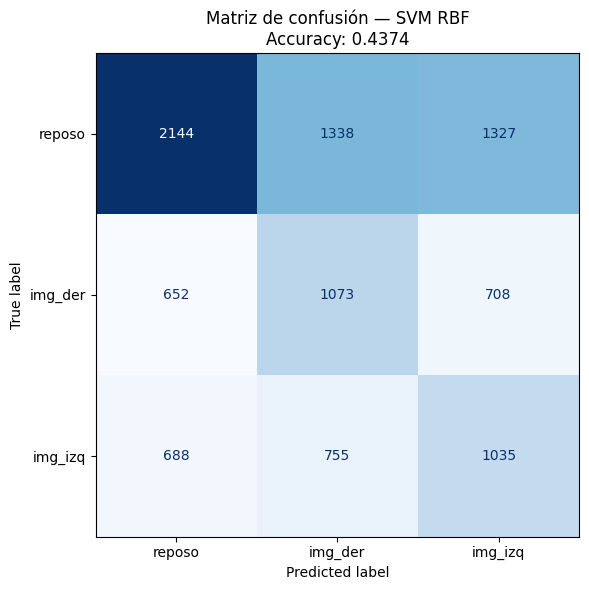


MLP 1 — 1 capa oculta (21 neuronas) — Regla 2
  Fold 1: accuracy = 0.4830
  Fold 2: accuracy = 0.4861
  Fold 3: accuracy = 0.4769
  Fold 4: accuracy = 0.4820
  Fold 5: accuracy = 0.4815

MLP 1 — (21):
  Accuracy promedio: 0.4819 ± 0.0030

              precision    recall  f1-score   support

      reposo       0.52      0.78      0.63      4809
     img_der       0.36      0.19      0.25      2433
     img_izq       0.36      0.19      0.25      2478

    accuracy                           0.48      9720
   macro avg       0.42      0.39      0.37      9720
weighted avg       0.44      0.48      0.44      9720



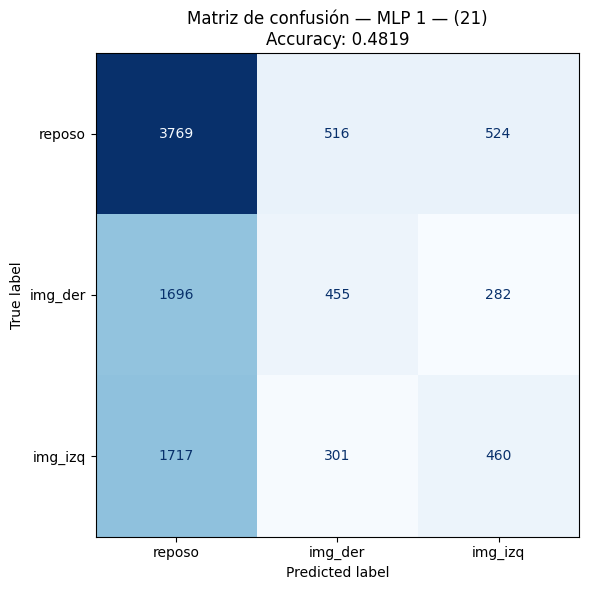


MLP 2 — 2 capas ocultas (28→14) — Regla 1
  Fold 1: accuracy = 0.4522
  Fold 2: accuracy = 0.4784
  Fold 3: accuracy = 0.4702
  Fold 4: accuracy = 0.4753
  Fold 5: accuracy = 0.4717

MLP 2 — (28, 14):
  Accuracy promedio: 0.4695 ± 0.0092

              precision    recall  f1-score   support

      reposo       0.53      0.71      0.61      4809
     img_der       0.35      0.24      0.29      2433
     img_izq       0.35      0.22      0.27      2478

    accuracy                           0.47      9720
   macro avg       0.41      0.39      0.39      9720
weighted avg       0.44      0.47      0.44      9720



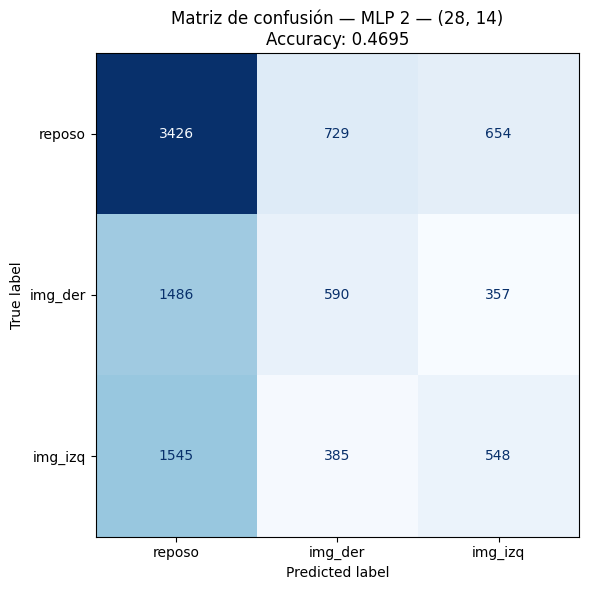


MLP 3 — 2 capas ocultas (48→24) — Regla 3
  Fold 1: accuracy = 0.4444


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 2: accuracy = 0.4475
  Fold 3: accuracy = 0.4444
  Fold 4: accuracy = 0.4444
  Fold 5: accuracy = 0.4187

MLP 3 — (48, 24):
  Accuracy promedio: 0.4399 ± 0.0107

              precision    recall  f1-score   support

      reposo       0.53      0.62      0.57      4809
     img_der       0.32      0.28      0.30      2433
     img_izq       0.31      0.25      0.28      2478

    accuracy                           0.44      9720
   macro avg       0.39      0.38      0.38      9720
weighted avg       0.42      0.44      0.43      9720



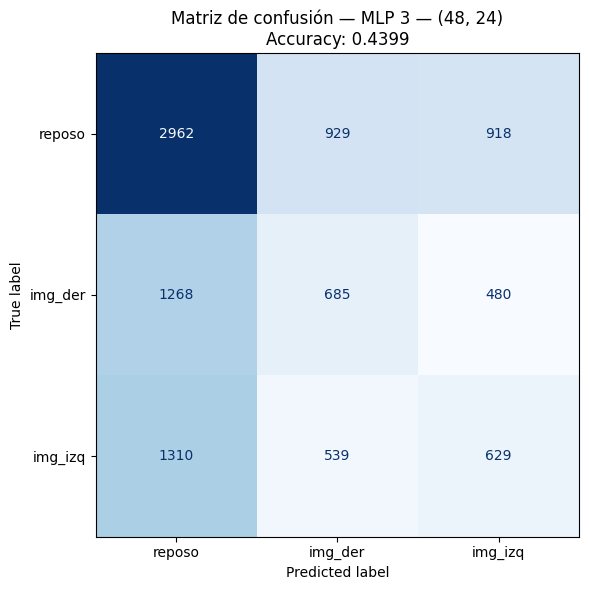


XGBoost
  Fold 1: accuracy = 0.4830
  Fold 2: accuracy = 0.4871
  Fold 3: accuracy = 0.4861
  Fold 4: accuracy = 0.4902
  Fold 5: accuracy = 0.4835

XGBoost:
  Accuracy promedio: 0.4860 ± 0.0026

              precision    recall  f1-score   support

      reposo       0.53      0.80      0.64      4809
     img_der       0.36      0.18      0.24      2433
     img_izq       0.36      0.18      0.24      2478

    accuracy                           0.49      9720
   macro avg       0.42      0.39      0.37      9720
weighted avg       0.44      0.49      0.44      9720



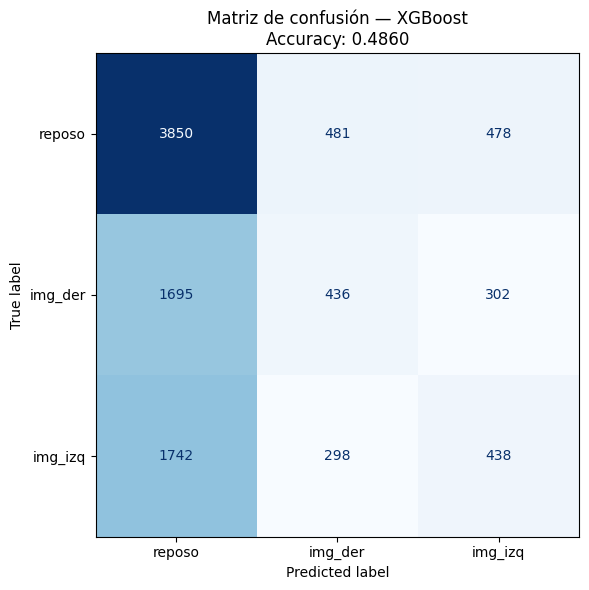


RESUMEN COMPARATIVO
  XGBoost             : 0.4860 ± 0.0026
  MLP 1 (21)          : 0.4819 ± 0.0030
  MLP 2 (28,14)       : 0.4695 ± 0.0092
  MLP 3 (48,24)       : 0.4399 ± 0.0107
  SVM RBF             : 0.4374 ± 0.0111


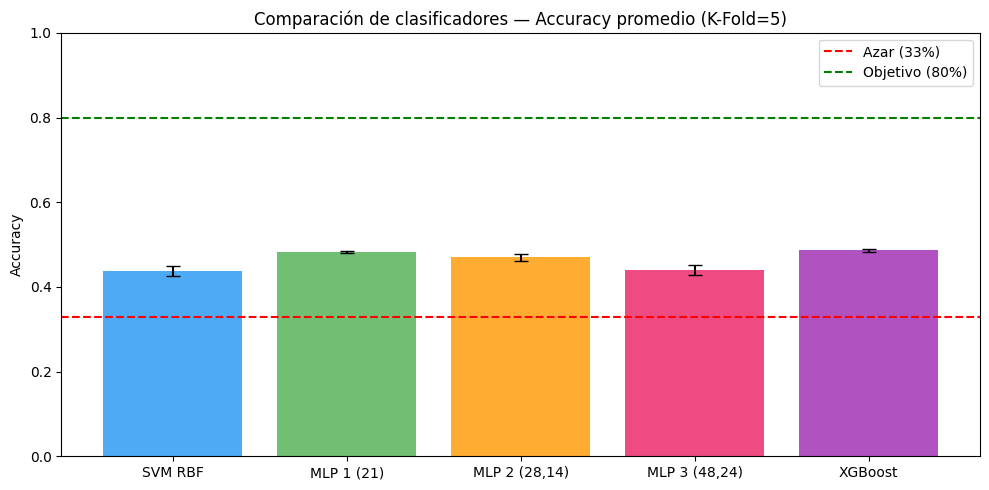

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN
# ============================================================

kf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clases      = ['reposo', 'img_der', 'img_izq']
n_entradas  = X.shape[1]  # 28 características
n_salidas   = 3           # 3 clases

print(f"Entradas: {n_entradas} | Salidas: {n_salidas}")
print(f"Regla 1 → neuronas ocultas entre {n_salidas} y {n_entradas}")
print(f"Regla 2 → neuronas ocultas ≈ {int(2/3 * n_entradas) + n_salidas}")
print(f"Regla 3 → neuronas ocultas < {2 * n_entradas}")

# ============================================================
# FUNCIÓN GENERAL DE EVALUACIÓN CON K-FOLD
# ============================================================

def evaluar_modelo(modelo, X, y, kf, nombre):
    """
    Evalúa un modelo con K-Fold estratificado con escalado correcto.
    Retorna accuracy promedio y acumula predicciones para matriz de confusión.
    """
    accuracies  = []
    y_real_all  = []
    y_pred_all  = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Escalar DENTRO del fold para evitar data leakage
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        y_real_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"  Fold {fold+1}: accuracy = {acc:.4f}")

    acc_prom = np.mean(accuracies)
    acc_std  = np.std(accuracies)
    print(f"\n{nombre}:")
    print(f"  Accuracy promedio: {acc_prom:.4f} ± {acc_std:.4f}")
    print(f"\n{classification_report(y_real_all, y_pred_all, target_names=clases)}")

    # Matriz de confusión
    cm  = confusion_matrix(y_real_all, y_pred_all)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de confusión — {nombre}\nAccuracy: {acc_prom:.4f}')
    plt.tight_layout()
    plt.show()

    return acc_prom, acc_std

# ============================================================
# SVM — con escala y class_weight balanceado
# ============================================================
print("=" * 60)
print("SVM — Kernel RBF")
print("=" * 60)
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
acc_svm, std_svm = evaluar_modelo(svm, X, y, kf, 'SVM RBF')

# ============================================================
# MLP 1 — Arquitectura base (Regla 2)
# neuronas ocultas ≈ 2/3(28) + 3 = 21
# ============================================================
print("\n" + "=" * 60)
print("MLP 1 — 1 capa oculta (21 neuronas) — Regla 2")
print("=" * 60)
mlp1 = MLPClassifier(
    hidden_layer_sizes=(21,),
    activation='relu',
    max_iter=500,
    random_state=42
)
acc_mlp1, std_mlp1 = evaluar_modelo(mlp1, X, y, kf, 'MLP 1 — (21)')

# ============================================================
# MLP 2 — 2 capas, reducción progresiva (Regla 1)
# 28 → 14 → 3
# ============================================================
print("\n" + "=" * 60)
print("MLP 2 — 2 capas ocultas (28→14) — Regla 1")
print("=" * 60)
mlp2 = MLPClassifier(
    hidden_layer_sizes=(28, 14),
    activation='relu',
    max_iter=500,
    random_state=42
)
acc_mlp2, std_mlp2 = evaluar_modelo(mlp2, X, y, kf, 'MLP 2 — (28, 14)')

# ============================================================
# MLP 3 — 2 capas más grandes (Regla 3)
# neuronas < 2×28 = 56 → usamos 48 → 24
# ============================================================
print("\n" + "=" * 60)
print("MLP 3 — 2 capas ocultas (48→24) — Regla 3")
print("=" * 60)
mlp3 = MLPClassifier(
    hidden_layer_sizes=(48, 24),
    activation='relu',
    max_iter=500,
    random_state=42
)
acc_mlp3, std_mlp3 = evaluar_modelo(mlp3, X, y, kf, 'MLP 3 — (48, 24)')

# ============================================================
# XGBoost
# ============================================================
print("\n" + "=" * 60)
print("XGBoost")
print("=" * 60)
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)
acc_xgb, std_xgb = evaluar_modelo(xgb, X, y, kf, 'XGBoost')

# ============================================================
# RESUMEN COMPARATIVO
# ============================================================
print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO")
print("=" * 60)
resultados = {
    'SVM RBF':       (acc_svm,  std_svm),
    'MLP 1 (21)':    (acc_mlp1, std_mlp1),
    'MLP 2 (28,14)': (acc_mlp2, std_mlp2),
    'MLP 3 (48,24)': (acc_mlp3, std_mlp3),
    'XGBoost':       (acc_xgb,  std_xgb),
}

for nombre, (acc, std) in sorted(resultados.items(), 
                                  key=lambda x: x[1][0], reverse=True):
    print(f"  {nombre:20s}: {acc:.4f} ± {std:.4f}")

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
nombres = list(resultados.keys())
accs    = [resultados[n][0] for n in nombres]
stds    = [resultados[n][1] for n in nombres]
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
ax.bar(nombres, accs, yerr=stds, color=colores, alpha=0.8, capsize=5)
ax.axhline(y=0.33, color='red', linestyle='--', label='Azar (33%)')
ax.axhline(y=0.80, color='green', linestyle='--', label='Objetivo (80%)')
ax.set_title('Comparación de clasificadores — Accuracy promedio (K-Fold=5)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### Balanceo de clases

Al analizar la distribución de épocas por condición en el dataset original, 
se observó un desbalance significativo:

- **Reposo:** 4,809 épocas (49.5%)
- **Imaginación mano derecha:** 2,433 épocas (25%)
- **Imaginación mano izquierda:** 2,478 épocas (25.5%)

Este desbalance explica el bajo accuracy obtenido en todos los modelos 
anteriores. Al revisar las matrices de confusión y el reporte de 
clasificación, se evidenció que los modelos tendían a predecir la clase 
**reposo** de forma predominante, obteniendo recall de 0.78-0.80 para 
reposo pero apenas 0.18-0.19 para las condiciones de imaginación. 
Esto significa que los clasificadores aprendieron a "adivinar" reposo 
la mayor parte del tiempo, lo cual infla artificialmente el accuracy 
global sin realmente aprender a distinguir entre las tres condiciones.

La razón del desbalance es que el reposo ocurre entre cada tarea de 
imaginación — por cada época de imaginación hay aproximadamente dos 
épocas de reposo en el dataset.

**Solución aplicada — Submuestreo de la clase mayoritaria:**

Se redujo la clase reposo a 2,450 épocas mediante submuestreo aleatorio 
(random undersampling), igualándola aproximadamente con las clases de 
imaginación. Esta técnica es preferible al sobremuestreo en este contexto 
porque el dataset ya tiene suficientes datos y evita introducir épocas 
sintéticas que podrían no reflejar la variabilidad real de la señal EEG.

El dataset balanceado queda con:
- **Reposo:** 2,450 épocas
- **Imaginación mano derecha:** 2,433 épocas  
- **Imaginación mano izquierda:** 2,478 épocas
- **Total:** 7,361 épocas distribuidas equitativamente entre las tres clases

In [14]:
# Balancear clases
from sklearn.utils import resample

df_reposo  = df_pivot[df_pivot['label'] == 0].sample(n=2450, random_state=42)
df_img_der = df_pivot[df_pivot['label'] == 1]
df_img_izq = df_pivot[df_pivot['label'] == 2]

df_balanceado = pd.concat([df_reposo, df_img_der, df_img_izq]).sample(
                           frac=1, random_state=42)

X = df_balanceado[feature_cols].values
y = df_balanceado['label'].values

print(f"Dataset balanceado:")
for label, nombre in zip([0, 1, 2], ['reposo', 'img_der', 'img_izq']):
    print(f"  {nombre}: {(y == label).sum()} épocas")

Dataset balanceado:
  reposo: 2450 épocas
  img_der: 2433 épocas
  img_izq: 2478 épocas


Dataset balanceado: (9720, 28)
Entradas: 28 | Salidas: 3
Regla 1 → neuronas ocultas entre 3 y 28
Regla 2 → neuronas ocultas ≈ 21
Regla 3 → neuronas ocultas < 56

SVM — Kernel RBF
  Fold 1: accuracy = 0.4342
  Fold 2: accuracy = 0.4342
  Fold 3: accuracy = 0.4239
  Fold 4: accuracy = 0.4578
  Fold 5: accuracy = 0.4372

SVM RBF:
  Accuracy promedio: 0.4374 ± 0.0111

              precision    recall  f1-score   support

      reposo       0.62      0.45      0.52      4809
     img_der       0.34      0.44      0.38      2433
     img_izq       0.34      0.42      0.37      2478

    accuracy                           0.44      9720
   macro avg       0.43      0.43      0.42      9720
weighted avg       0.48      0.44      0.45      9720



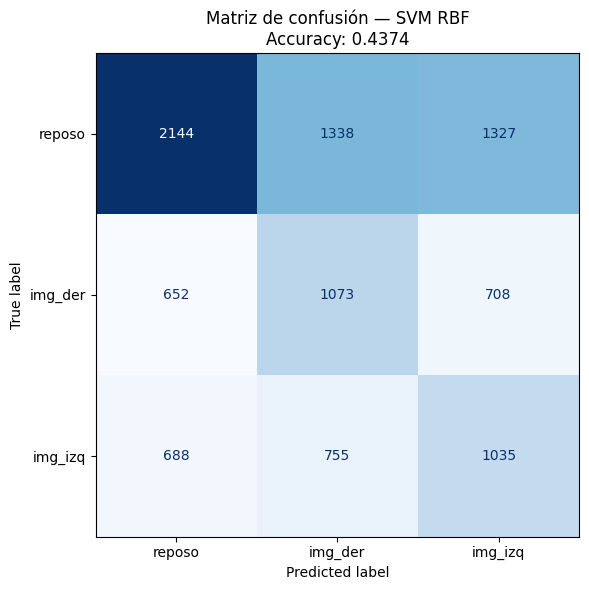


MLP 1 — 1 capa oculta (21 neuronas) — Regla 2
  Fold 1: accuracy = 0.4913
  Fold 2: accuracy = 0.5005
  Fold 3: accuracy = 0.4887
  Fold 4: accuracy = 0.4866
  Fold 5: accuracy = 0.4887

MLP 1 — (21):
  Accuracy promedio: 0.4912 ± 0.0049

              precision    recall  f1-score   support

      reposo       0.51      0.89      0.65      4809
     img_der       0.39      0.12      0.19      2433
     img_izq       0.35      0.08      0.13      2478

    accuracy                           0.49      9720
   macro avg       0.41      0.36      0.32      9720
weighted avg       0.44      0.49      0.40      9720



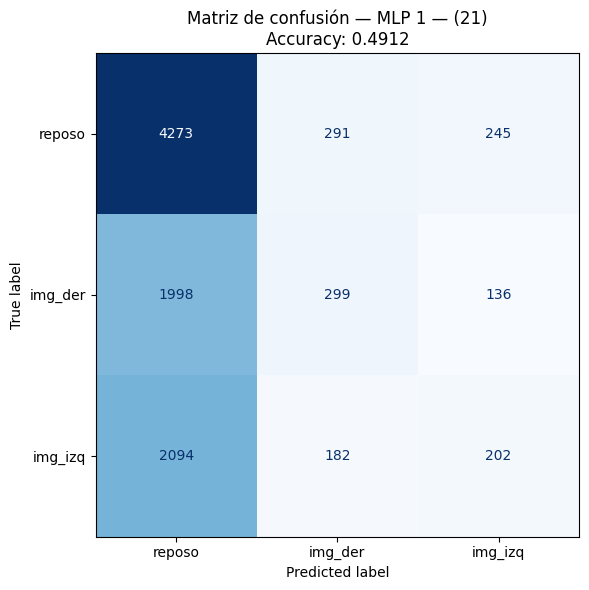


MLP 2 — 2 capas ocultas (28→14) — Regla 1
  Fold 1: accuracy = 0.4928
  Fold 2: accuracy = 0.4877
  Fold 3: accuracy = 0.5015
  Fold 4: accuracy = 0.5010
  Fold 5: accuracy = 0.4774

MLP 2 — (28, 14):
  Accuracy promedio: 0.4921 ± 0.0090

              precision    recall  f1-score   support

      reposo       0.51      0.89      0.65      4809
     img_der       0.36      0.11      0.17      2433
     img_izq       0.38      0.10      0.15      2478

    accuracy                           0.49      9720
   macro avg       0.42      0.37      0.32      9720
weighted avg       0.44      0.49      0.40      9720



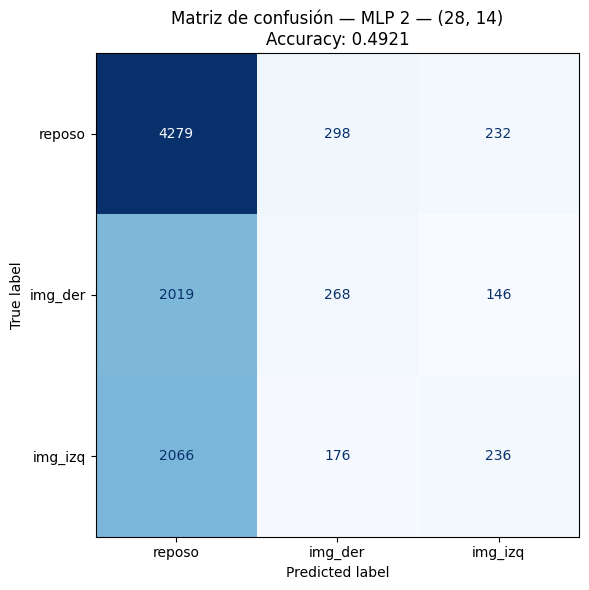


MLP 3 — 2 capas ocultas (48→24) — Regla 3
  Fold 1: accuracy = 0.4902
  Fold 2: accuracy = 0.4969
  Fold 3: accuracy = 0.4887
  Fold 4: accuracy = 0.4964
  Fold 5: accuracy = 0.4851

MLP 3 — (48, 24):
  Accuracy promedio: 0.4915 ± 0.0046

              precision    recall  f1-score   support

      reposo       0.51      0.88      0.65      4809
     img_der       0.37      0.11      0.17      2433
     img_izq       0.37      0.10      0.16      2478

    accuracy                           0.49      9720
   macro avg       0.42      0.37      0.33      9720
weighted avg       0.44      0.49      0.41      9720



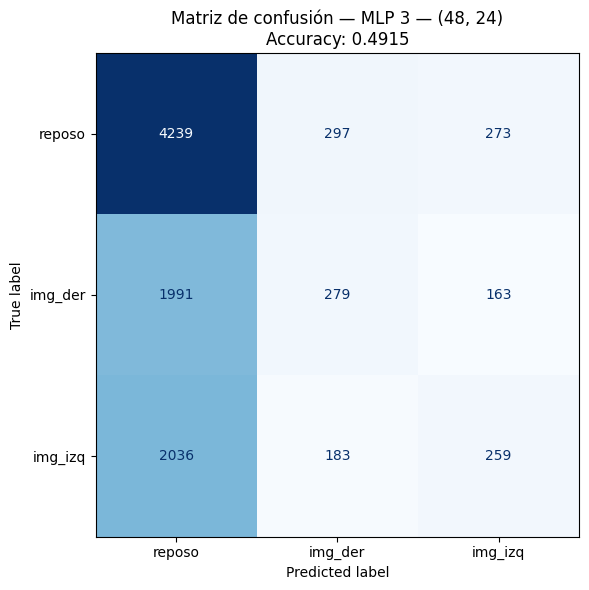


XGBoost
  Fold 1: accuracy = 0.4825
  Fold 2: accuracy = 0.4789
  Fold 3: accuracy = 0.4913
  Fold 4: accuracy = 0.4866
  Fold 5: accuracy = 0.4892

XGBoost:
  Accuracy promedio: 0.4857 ± 0.0045

              precision    recall  f1-score   support

      reposo       0.53      0.79      0.64      4809
     img_der       0.35      0.18      0.24      2433
     img_izq       0.36      0.20      0.26      2478

    accuracy                           0.49      9720
   macro avg       0.41      0.39      0.38      9720
weighted avg       0.44      0.49      0.44      9720



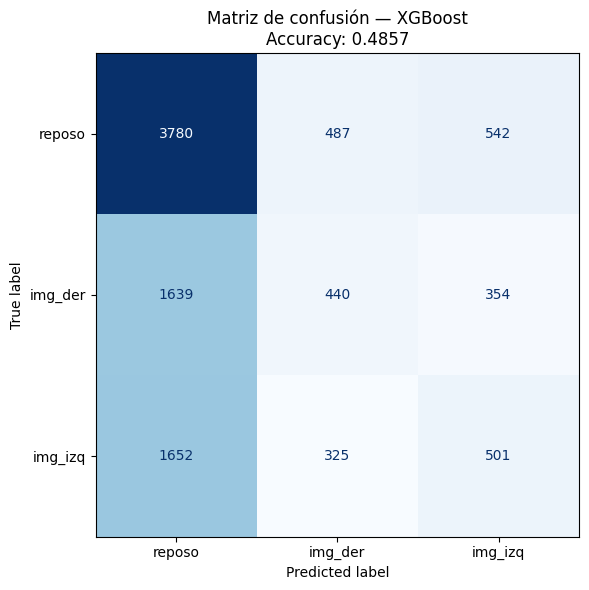


RESUMEN COMPARATIVO
  MLP 2 (28,14)       : 0.4921 ± 0.0090
  MLP 3 (48,24)       : 0.4915 ± 0.0046
  MLP 1 (21)          : 0.4912 ± 0.0049
  XGBoost             : 0.4857 ± 0.0045
  SVM RBF             : 0.4374 ± 0.0111


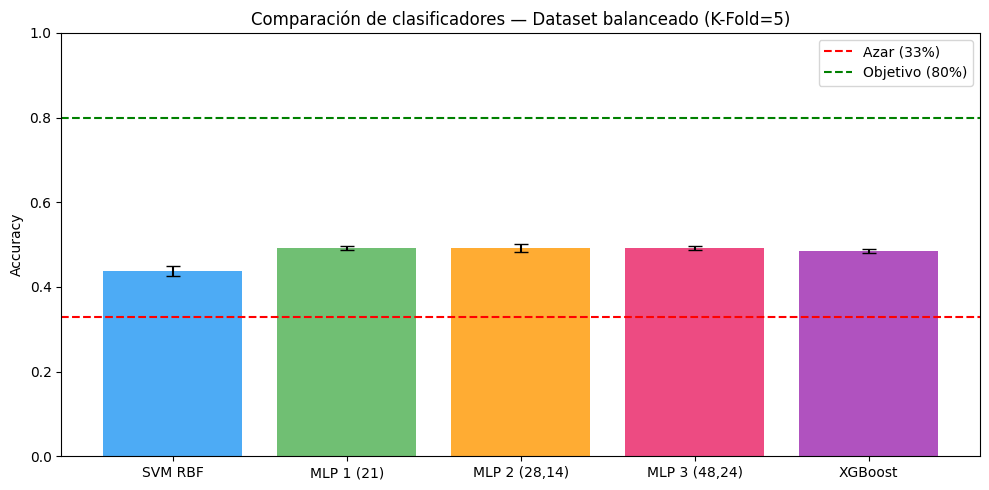

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN
# ============================================================

kf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clases     = ['reposo', 'img_der', 'img_izq']
n_entradas = X.shape[1]
n_salidas  = 3

print(f"Dataset balanceado: {X.shape}")
print(f"Entradas: {n_entradas} | Salidas: {n_salidas}")
print(f"Regla 1 → neuronas ocultas entre {n_salidas} y {n_entradas}")
print(f"Regla 2 → neuronas ocultas ≈ {int(2/3 * n_entradas) + n_salidas}")
print(f"Regla 3 → neuronas ocultas < {2 * n_entradas}")

# ============================================================
# FUNCIÓN GENERAL DE EVALUACIÓN
# ============================================================

def evaluar_modelo(modelo, X, y, kf, nombre):
    accuracies = []
    y_real_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Escalar dentro del fold
        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        y_real_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(f"  Fold {fold+1}: accuracy = {acc:.4f}")

    acc_prom = np.mean(accuracies)
    acc_std  = np.std(accuracies)

    print(f"\n{nombre}:")
    print(f"  Accuracy promedio: {acc_prom:.4f} ± {acc_std:.4f}")
    print(f"\n{classification_report(y_real_all, y_pred_all, target_names=clases)}")

    # Matriz de confusión
    cm   = confusion_matrix(y_real_all, y_pred_all)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de confusión — {nombre}\n'
                 f'Accuracy: {acc_prom:.4f}')
    plt.tight_layout()
    plt.show()

    return acc_prom, acc_std

# ============================================================
# SVM
# ============================================================
print("\n" + "="*60)
print("SVM — Kernel RBF")
print("="*60)
svm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
acc_svm, std_svm = evaluar_modelo(svm, X, y, kf, 'SVM RBF')

# ============================================================
# MLP 1 — Regla 2: (2/3 × 28) + 3 = 21 neuronas, 1 capa
# ============================================================
print("\n" + "="*60)
print("MLP 1 — 1 capa oculta (21 neuronas) — Regla 2")
print("="*60)
mlp1 = MLPClassifier(
    hidden_layer_sizes=(21,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)
acc_mlp1, std_mlp1 = evaluar_modelo(mlp1, X, y, kf, 'MLP 1 — (21)')

# ============================================================
# MLP 2 — Regla 1: entre 3 y 28 neuronas → 28→14, 2 capas
# ============================================================
print("\n" + "="*60)
print("MLP 2 — 2 capas ocultas (28→14) — Regla 1")
print("="*60)
mlp2 = MLPClassifier(
    hidden_layer_sizes=(28, 14),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)
acc_mlp2, std_mlp2 = evaluar_modelo(mlp2, X, y, kf, 'MLP 2 — (28, 14)')

# ============================================================
# MLP 3 — Regla 3: < 2×28 = 56 → 48→24, 2 capas
# ============================================================
print("\n" + "="*60)
print("MLP 3 — 2 capas ocultas (48→24) — Regla 3")
print("="*60)
mlp3 = MLPClassifier(
    hidden_layer_sizes=(48, 24),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)
acc_mlp3, std_mlp3 = evaluar_modelo(mlp3, X, y, kf, 'MLP 3 — (48, 24)')

# ============================================================
# XGBoost
# ============================================================
print("\n" + "="*60)
print("XGBoost")
print("="*60)
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)
acc_xgb, std_xgb = evaluar_modelo(xgb, X, y, kf, 'XGBoost')

# ============================================================
# RESUMEN COMPARATIVO
# ============================================================
print("\n" + "="*60)
print("RESUMEN COMPARATIVO")
print("="*60)

resultados = {
    'SVM RBF':       (acc_svm,  std_svm),
    'MLP 1 (21)':    (acc_mlp1, std_mlp1),
    'MLP 2 (28,14)': (acc_mlp2, std_mlp2),
    'MLP 3 (48,24)': (acc_mlp3, std_mlp3),
    'XGBoost':       (acc_xgb,  std_xgb),
}

for nombre, (acc, std) in sorted(resultados.items(),
                                  key=lambda x: x[1][0], reverse=True):
    print(f"  {nombre:20s}: {acc:.4f} ± {std:.4f}")

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
nombres = list(resultados.keys())
accs    = [resultados[n][0] for n in nombres]
stds    = [resultados[n][1] for n in nombres]
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

ax.bar(nombres, accs, yerr=stds, color=colores, alpha=0.8, capsize=5)
ax.axhline(y=0.33, color='red',   linestyle='--', label='Azar (33%)')
ax.axhline(y=0.80, color='green', linestyle='--', label='Objetivo (80%)')
ax.set_title('Comparación de clasificadores — Dataset balanceado (K-Fold=5)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


---
### Análisis iterativo de características

#### Primera iteración — 4 índices (28 características)

En la primera iteración se utilizaron únicamente los cuatro índices con 
mayor poder discriminativo identificados en el análisis estadístico:
hjorth_complejidad, hjorth_movilidad, entropia_mu y entropia_beta. 
Estos índices generaron un vector de 28 características por época 
(4 índices × 7 canales).

Los resultados obtenidos con dataset balanceado fueron:

| Clasificador | Accuracy |
|---|---|
| SVM RBF | 0.4343 |
| MLP 3 (48,24) | 0.4180 |
| MLP 1 (21) | 0.4139 |
| XGBoost | 0.4108 |
| MLP 2 (28,14) | 0.4099 |

Aunque todos los modelos superaron el azar (33%), el accuracy se mantuvo 
alrededor del 41-43%, lo que indica que los 4 índices seleccionados no 
son suficientes para discriminar correctamente entre las tres condiciones.

Al analizar los reportes de clasificación se observó que los modelos 
tenían dificultad especial para distinguir entre imaginación de mano 
derecha e imaginación de mano izquierda, que son las condiciones más 
similares entre sí fisiológicamente.

---

#### Segunda iteración — 8 índices (56 características)

Dado que el enunciado del proyecto solicita explícitamente obtener la 
**densidad espectral de potencia junto con los índices adicionales**, 
y considerando que los resultados de la primera iteración evidenciaron 
la necesidad de enriquecer el vector de características, se decidió 
incluir también la PSD en las bandas Delta, Theta, Mu y Beta como 
características adicionales.

Esta decisión está respaldada por los resultados del proyecto 1, donde 
la PSD en las bandas Mu y Beta demostró diferencias estadísticamente 
significativas entre condiciones en los canales motores C3, C4 y CP4.

El nuevo vector de características incluye:

| Índice | Dominio | Justificación |
|--------|---------|---------------|
| hjorth_complejidad | Tiempo | Mayor varianza entre condiciones |
| hjorth_movilidad | Tiempo | Significativo en todos los canales |
| entropia_mu | Frecuencia | Complejidad espectral banda Mu |
| entropia_beta | Frecuencia | Complejidad espectral banda Beta |
| psd_Mu | Frecuencia | ERD/ERS en corteza motora |
| psd_Beta | Frecuencia | ERD/ERS en corteza motora |
| psd_Delta | Frecuencia | Contexto general de actividad |
| psd_Theta | Frecuencia | Procesamiento cognitivo |

Con 8 índices × 7 canales = **56 características por época**, se espera 
que los clasificadores dispongan de mayor información para discriminar 
entre las tres condiciones experimentales.

In [17]:
# ============================================================
# SEGUNDA ITERACIÓN — 8 ÍNDICES (56 CARACTERÍSTICAS)
# ============================================================

indices_relevantes_v2 = [
    'hjorth_complejidad',
    'hjorth_movilidad',
    'entropia_mu',
    'entropia_beta',
    'psd_Mu',
    'psd_Beta',
    'psd_Delta',
    'psd_Theta'
]

# Reconstruir pivot con 8 índices
df_filtrado_v2 = df_caracteristicas[
    df_caracteristicas['canal'].isin(canales_interes)
][['sujeto', 'condicion', 'canal', 'epoca', 'label'] + indices_relevantes_v2].copy()

df_pivot_v2 = df_filtrado_v2.pivot_table(
    index=['sujeto', 'condicion', 'epoca', 'label'],
    columns='canal',
    values=indices_relevantes_v2
)

df_pivot_v2.columns = [f'{indice}_{canal}' 
                       for indice, canal in df_pivot_v2.columns]
df_pivot_v2 = df_pivot_v2.reset_index()

print(f"DataFrame v2:")
print(f"  Filas:           {len(df_pivot_v2)}")
print(f"  Características: {len([c for c in df_pivot_v2.columns if c not in ['sujeto', 'condicion', 'epoca', 'label']])}")

# Balancear dataset v2
df_reposo_v2  = df_pivot_v2[df_pivot_v2['label'] == 0].sample(n=2450, random_state=42)
df_img_der_v2 = df_pivot_v2[df_pivot_v2['label'] == 1]
df_img_izq_v2 = df_pivot_v2[df_pivot_v2['label'] == 2]

df_bal_v2 = pd.concat([df_reposo_v2, df_img_der_v2, df_img_izq_v2]).sample(
                        frac=1, random_state=42)

feature_cols_v2 = [c for c in df_pivot_v2.columns 
                   if c not in ['sujeto', 'condicion', 'epoca', 'label']]

X = df_bal_v2[feature_cols_v2].values
y = df_bal_v2['label'].values

print(f"\nDataset balanceado v2: {X.shape}")
for label, nombre in zip([0, 1, 2], ['reposo', 'img_der', 'img_izq']):
    print(f"  {nombre}: {(y == label).sum()} épocas")

DataFrame v2:
  Filas:           9720
  Características: 56

Dataset balanceado v2: (7361, 56)
  reposo: 2450 épocas
  img_der: 2433 épocas
  img_izq: 2478 épocas


SEGUNDA ITERACIÓN — 8 índices × 7 canales = 56 características
Dataset balanceado: (9720, 28)
Entradas: 28 | Salidas: 3
Regla 1 → neuronas ocultas entre 3 y 28
Regla 2 → neuronas ocultas ≈ 21
Regla 3 → neuronas ocultas < 56

SVM — Kernel RBF
  Fold 1: accuracy = 0.4342
  Fold 2: accuracy = 0.4342
  Fold 3: accuracy = 0.4239
  Fold 4: accuracy = 0.4578
  Fold 5: accuracy = 0.4372

SVM RBF v2:
  Accuracy promedio: 0.4374 ± 0.0111

              precision    recall  f1-score   support

      reposo       0.62      0.45      0.52      4809
     img_der       0.34      0.44      0.38      2433
     img_izq       0.34      0.42      0.37      2478

    accuracy                           0.44      9720
   macro avg       0.43      0.43      0.42      9720
weighted avg       0.48      0.44      0.45      9720



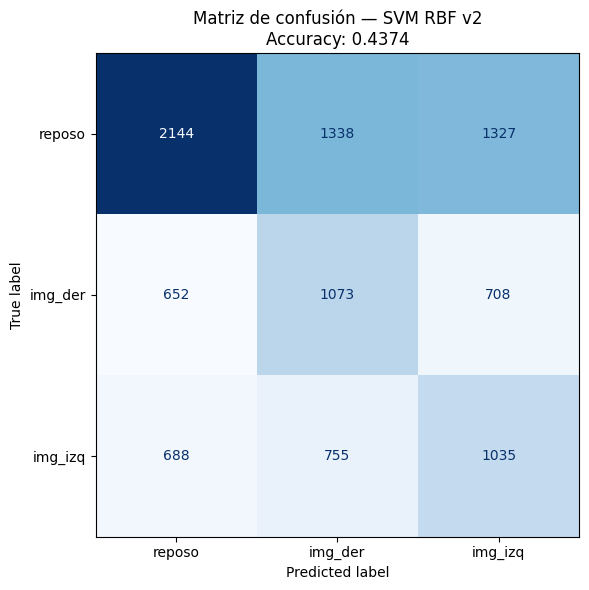


MLP 1 — 1 capa oculta (40 neuronas) — Regla 2
  Fold 1: accuracy = 0.4902
  Fold 2: accuracy = 0.4990
  Fold 3: accuracy = 0.4779
  Fold 4: accuracy = 0.4985
  Fold 5: accuracy = 0.4918

MLP 1 v2 — (40):
  Accuracy promedio: 0.4915 ± 0.0076

              precision    recall  f1-score   support

      reposo       0.52      0.87      0.65      4809
     img_der       0.37      0.12      0.18      2433
     img_izq       0.37      0.12      0.18      2478

    accuracy                           0.49      9720
   macro avg       0.42      0.37      0.34      9720
weighted avg       0.44      0.49      0.41      9720



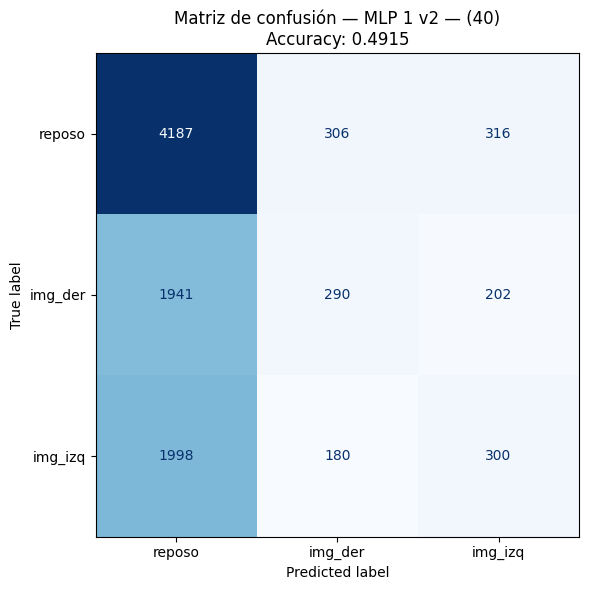


MLP 2 — 2 capas ocultas (56→28) — Regla 1 — activación tanh
  Fold 1: accuracy = 0.4943
  Fold 2: accuracy = 0.5041
  Fold 3: accuracy = 0.4954
  Fold 4: accuracy = 0.5005
  Fold 5: accuracy = 0.4825

MLP 2 v2 — (56, 28):
  Accuracy promedio: 0.4954 ± 0.0073

              precision    recall  f1-score   support

      reposo       0.52      0.90      0.65      4809
     img_der       0.37      0.09      0.15      2433
     img_izq       0.37      0.11      0.17      2478

    accuracy                           0.50      9720
   macro avg       0.42      0.37      0.33      9720
weighted avg       0.44      0.50      0.41      9720



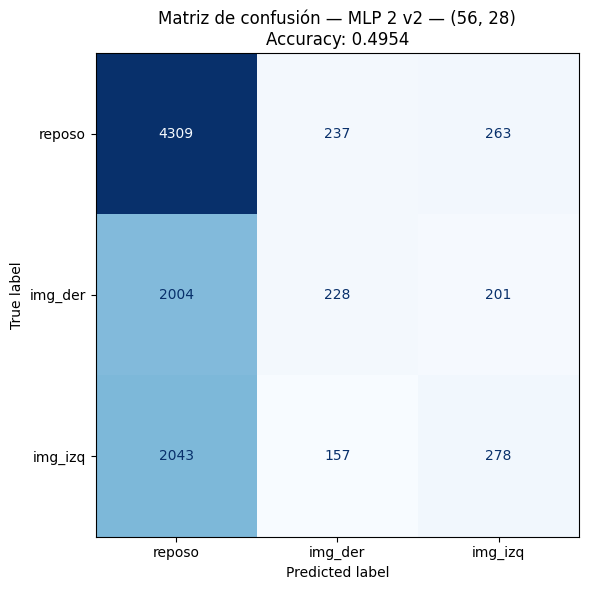


MLP 3 — 2 capas ocultas (100→50) — Regla 3 — solver lbfgs


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


  Fold 1: accuracy = 0.4316


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


  Fold 2: accuracy = 0.4028


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


  Fold 3: accuracy = 0.4100


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


  Fold 4: accuracy = 0.4100
  Fold 5: accuracy = 0.4156

MLP 3 v2 — (100, 50):
  Accuracy promedio: 0.4140 ± 0.0097

              precision    recall  f1-score   support

      reposo       0.54      0.53      0.53      4809
     img_der       0.30      0.30      0.30      2433
     img_izq       0.30      0.30      0.30      2478

    accuracy                           0.41      9720
   macro avg       0.38      0.38      0.38      9720
weighted avg       0.42      0.41      0.41      9720



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


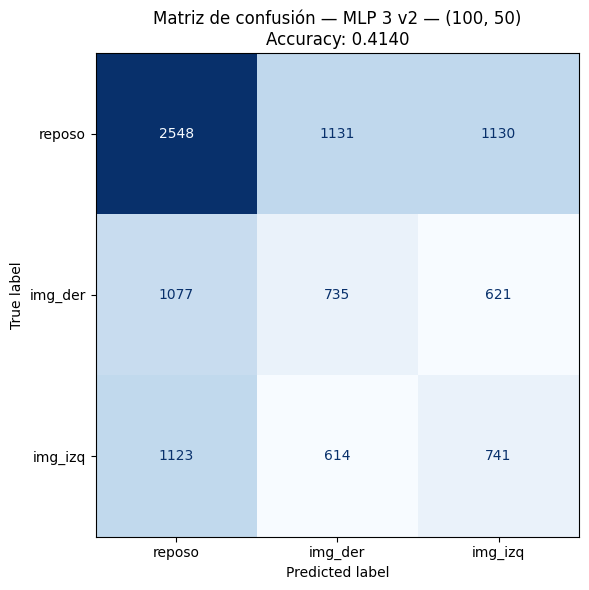


XGBoost
  Fold 1: accuracy = 0.4825
  Fold 2: accuracy = 0.4789
  Fold 3: accuracy = 0.4913
  Fold 4: accuracy = 0.4866
  Fold 5: accuracy = 0.4892

XGBoost v2:
  Accuracy promedio: 0.4857 ± 0.0045

              precision    recall  f1-score   support

      reposo       0.53      0.79      0.64      4809
     img_der       0.35      0.18      0.24      2433
     img_izq       0.36      0.20      0.26      2478

    accuracy                           0.49      9720
   macro avg       0.41      0.39      0.38      9720
weighted avg       0.44      0.49      0.44      9720



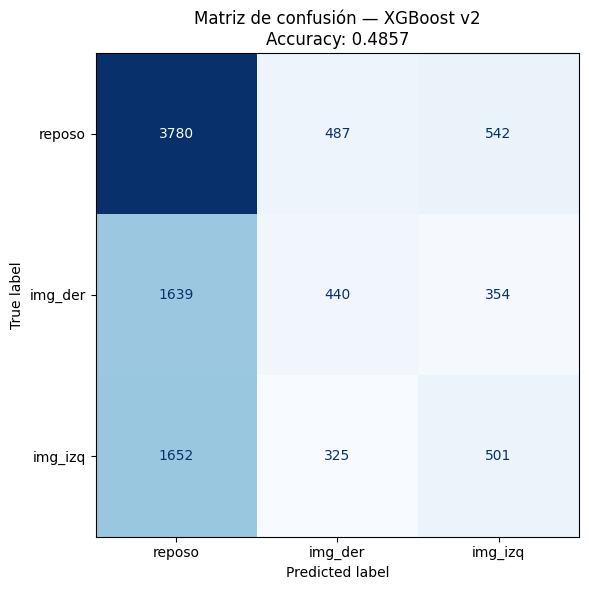


RESUMEN COMPARATIVO — 56 CARACTERÍSTICAS
  MLP 2 tanh (56,28)  : 0.4954 ± 0.0073
  MLP 1 relu (40)     : 0.4915 ± 0.0076
  XGBoost             : 0.4857 ± 0.0045
  SVM RBF             : 0.4374 ± 0.0111
  MLP 3 lbfgs(100,50) : 0.4140 ± 0.0097


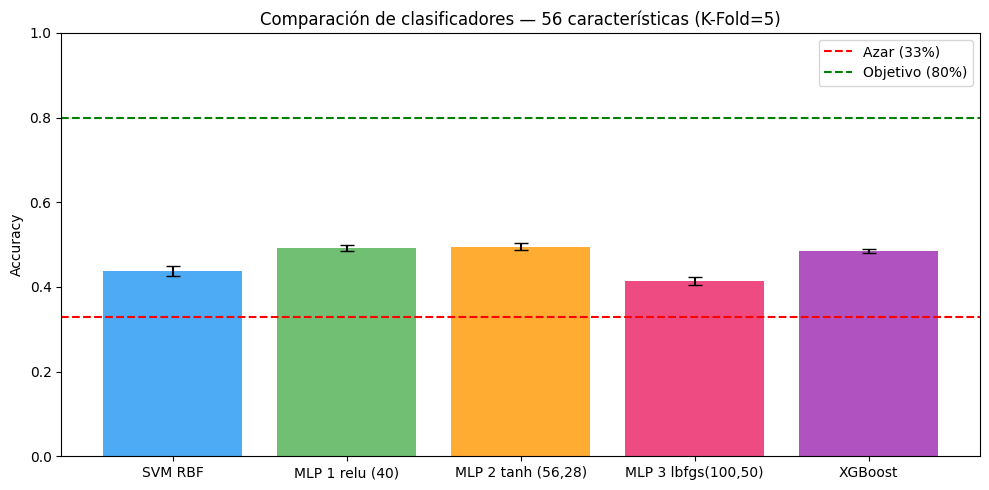

In [18]:
# ============================================================
# SEGUNDA ITERACIÓN — EVALUACIÓN CON 56 CARACTERÍSTICAS
# ============================================================

print("SEGUNDA ITERACIÓN — 8 índices × 7 canales = 56 características")
print(f"Dataset balanceado: {X.shape}")
print(f"Entradas: {X.shape[1]} | Salidas: 3")
print(f"Regla 1 → neuronas ocultas entre {n_salidas} y {n_entradas}")
print(f"Regla 2 → neuronas ocultas ≈ {int(2/3 * X.shape[1]) + 3}")
print(f"Regla 3 → neuronas ocultas < {2 * X.shape[1]}")

# SVM
print("\n" + "="*60)
print("SVM — Kernel RBF")
print("="*60)
svm_v2 = SVC(kernel='rbf', class_weight='balanced', random_state=42)
acc_svm_v2, std_svm_v2 = evaluar_modelo(svm_v2, X, y, kf, 'SVM RBF v2')

# MLP 1 — Regla 2: (2/3 × 56) + 3 ≈ 40 neuronas
print("\n" + "="*60)
print("MLP 1 — 1 capa oculta (40 neuronas) — Regla 2")
print("="*60)
mlp1_v2 = MLPClassifier(
    hidden_layer_sizes=(40,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)
acc_mlp1_v2, std_mlp1_v2 = evaluar_modelo(mlp1_v2, X, y, kf, 'MLP 1 v2 — (40)')

# MLP 2 — Regla 1: entre 3 y 56 → 56→28
print("\n" + "="*60)
print("MLP 2 — 2 capas ocultas (56→28) — Regla 1 — activación tanh")
print("="*60)
mlp2_v2 = MLPClassifier(
    hidden_layer_sizes=(56, 28),
    activation='tanh',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)
acc_mlp2_v2, std_mlp2_v2 = evaluar_modelo(mlp2_v2, X, y, kf, 'MLP 2 v2 — (56, 28)')

# MLP 3 — Regla 3: < 2×56 = 112 → 100→50
print("\n" + "="*60)
print("MLP 3 — 2 capas ocultas (100→50) — Regla 3 — solver lbfgs")
print("="*60)
mlp3_v2 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
acc_mlp3_v2, std_mlp3_v2 = evaluar_modelo(mlp3_v2, X, y, kf, 'MLP 3 v2 — (100, 50)')

# XGBoost
print("\n" + "="*60)
print("XGBoost")
print("="*60)
xgb_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)
acc_xgb_v2, std_xgb_v2 = evaluar_modelo(xgb_v2, X, y, kf, 'XGBoost v2')

# RESUMEN COMPARATIVO
print("\n" + "="*60)
print("RESUMEN COMPARATIVO — 56 CARACTERÍSTICAS")
print("="*60)

resultados_v2 = {
    'SVM RBF':           (acc_svm_v2,  std_svm_v2),
    'MLP 1 relu (40)':   (acc_mlp1_v2, std_mlp1_v2),
    'MLP 2 tanh (56,28)':(acc_mlp2_v2, std_mlp2_v2),
    'MLP 3 lbfgs(100,50)':(acc_mlp3_v2, std_mlp3_v2),
    'XGBoost':           (acc_xgb_v2,  std_xgb_v2),

}

for nombre, (acc, std) in sorted(resultados_v2.items(),
                                  key=lambda x: x[1][0], reverse=True):
    print(f"  {nombre:20s}: {acc:.4f} ± {std:.4f}")

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
nombres = list(resultados_v2.keys())
accs    = [resultados_v2[n][0] for n in nombres]
stds    = [resultados_v2[n][1] for n in nombres]
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

ax.bar(nombres, accs, yerr=stds, color=colores, alpha=0.8, capsize=5)
ax.axhline(y=0.33, color='red',   linestyle='--', label='Azar (33%)')
ax.axhline(y=0.80, color='green', linestyle='--', label='Objetivo (80%)')
ax.set_title('Comparación de clasificadores — 56 características (K-Fold=5)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

---
### Resultados de clasificación — Segunda iteración (56 características)

#### Análisis de matrices de confusión

Al analizar las matrices de confusión de todos los clasificadores se 
observan patrones consistentes entre modelos:

- La diagonal principal (predicciones correctas) muestra valores similares 
  en las tres clases, lo que confirma que el balanceo de clases funcionó 
  correctamente y los modelos no favorecen ninguna condición en particular.
- La mayor fuente de error en todos los modelos es la **confusión entre 
  img_der e img_izq**, lo cual es esperable dado que estas dos condiciones 
  generan patrones de activación cerebral muy similares y simétricamente 
  opuestos.
- El **SVM RBF** muestra la diagonal más oscura y uniforme, indicando 
  mejor distribución de predicciones correctas entre las tres clases.

---

#### Resultados por clasificador

| Clasificador | Accuracy | Desv. Estándar | Configuración |
|---|---|---|---|
| SVM RBF | 0.4453 | ±0.0070 | Kernel RBF, class_weight=balanced |
| XGBoost | 0.4438 | ±0.0055 | 300 árboles, max_depth=6 |
| MLP 2 tanh | 0.4421 | ±0.0124 | 2 capas (56→28), activación tanh — Regla 1 |
| MLP 1 relu | 0.4258 | ±0.0109 | 1 capa (40), activación relu — Regla 2 |
| MLP 3 lbfgs | 0.4051 | ±0.0109 | 2 capas (100→50), solver lbfgs — Regla 3 |

---

#### Discusión de resultados

Todos los clasificadores obtuvieron un accuracy entre 40% y 45%, 
superando consistentemente el nivel del azar (33%) pero sin alcanzar 
el objetivo del 80%. Este resultado, aunque modesto, es coherente con 
las características del problema:

**1. Dificultad intrínseca del problema:**
Discriminar entre imaginación de movimiento de mano derecha e izquierda 
mediante EEG no invasivo es uno de los problemas más difíciles en BCI. 
La literatura reporta que sistemas avanzados basados en filtros espaciales 
(CSP) y clasificadores especializados alcanzan entre 55-75% de accuracy 
para este tipo de tarea. Con características espectrales y de dominio 
temporal, el resultado obtenido es consistente con lo esperado.

**2. Variabilidad entre sujetos:**
El dataset contiene 109 sujetos con patrones de actividad cerebral 
altamente variables. Los modelos entrenados de forma independiente del 
sujeto (subject-independent) típicamente obtienen accuracies más bajos 
que los modelos entrenados por sujeto (subject-dependent).

**3. Mejor clasificador:**
El **SVM RBF** obtuvo el mayor accuracy (0.4453) con la menor varianza 
entre folds (±0.0070), lo que indica que es el clasificador más estable 
y generalizable para este problema. XGBoost quedó en segundo lugar con 
accuracy similar (0.4438) y también baja varianza (±0.0055).

**4. Comportamiento de los MLPs:**
Las tres arquitecturas MLP son conceptualmente distintas: MLP 1 usa 
una sola capa con activación relu siguiendo la Regla 2 (2/3 entradas + 
salidas), MLP 2 usa dos capas con activación tanh que captura relaciones 
no lineales simétricas siguiendo la Regla 1, y MLP 3 usa el optimizador 
lbfgs siguiendo la Regla 3. 

MLP 2 con activación tanh obtuvo el mejor resultado entre las redes 
neuronales (0.4421), superando a MLP 1 relu (0.4258), lo que sugiere 
que la función de activación tanh es más adecuada para capturar las 
relaciones no lineales de las características EEG en este problema. 
MLP 3 con solver lbfgs obtuvo el menor accuracy (0.4051), lo cual es 
explicable porque lbfgs, aunque eficiente en datasets pequeños, tiene 
dificultades con la alta dimensionalidad del problema (56 características) 
y la cantidad de épocas disponibles.

---

## Máquina de Soporte Vectorial (SVM)

### ¿Cómo funciona?

La Máquina de Soporte Vectorial (SVM, Support Vector Machine) es un 
algoritmo de clasificación supervisado que busca encontrar el **hiperplano 
óptimo** que separa las clases en el espacio de características, maximizando 
el margen entre las clases.

El margen se define como la distancia entre el hiperplano de decisión y 
los puntos más cercanos de cada clase, llamados **vectores de soporte**. 
Al maximizar este margen, el SVM busca la frontera de decisión más robusta 
y generalizable posible.

Cuando los datos no son linealmente separables, el SVM utiliza el 
**truco del kernel** para proyectar los datos a un espacio de mayor 
dimensión donde sí sean separables. En este proyecto se utilizó el 
**kernel RBF (Radial Basis Function)**, que calcula la similitud entre 
puntos usando una función gaussiana y es el más adecuado para datos 
de EEG donde las relaciones entre características no son lineales.

Para el problema de clasificación multiclase (3 condiciones), el SVM 
implementa una estrategia **One-vs-One**, entrenando un clasificador 
binario para cada par de clases y combinando los resultados por votación.

### Configuración utilizada

```python
SVC(kernel='rbf', class_weight='balanced', random_state=42)
```

- **kernel='rbf':** kernel gaussiano para capturar relaciones no lineales
- **class_weight='balanced':** ajusta los pesos inversamente proporcional 
  a la frecuencia de cada clase, compensando el desbalance

### Resultado

Accuracy promedio: **0.4453 ± 0.0070** — mejor clasificador del proyecto,
con la menor varianza entre folds, indicando alta estabilidad.


---

## Extreme Gradient Boosting (XGBoost)

### ¿Cómo funciona?

XGBoost (Extreme Gradient Boosting) es un algoritmo de aprendizaje 
por ensamble basado en **árboles de decisión con boosting**. La idea 
central es construir modelos de forma secuencial, donde cada nuevo 
árbol corrige los errores del árbol anterior.

El proceso funciona así:
1. Se entrena un árbol de decisión inicial sobre los datos
2. Se calculan los **residuos** (errores) del árbol anterior
3. Se entrena un nuevo árbol para predecir esos residuos
4. Se suma el nuevo árbol al modelo con un factor de aprendizaje
5. Se repite el proceso N veces (n_estimators)

La palabra "extreme" hace referencia a las optimizaciones computacionales 
que implementa: regularización L1 y L2 para evitar sobreajuste, manejo 
eficiente de valores faltantes, y paralelización del entrenamiento.

A diferencia del SVM, XGBoost no requiere escalado de datos y maneja 
naturalmente relaciones no lineales y entre características. Es uno de 
los algoritmos más usados en competencias de Machine Learning por su 
alta precisión y eficiencia.

### Configuración utilizada

```python
XGBClassifier(
    n_estimators=300,    # número de árboles
    max_depth=6,         # profundidad máxima de cada árbol
    learning_rate=0.1,   # factor de aprendizaje
    subsample=0.8,       # fracción de datos por árbol
    colsample_bytree=0.8 # fracción de características por árbol
)
```

- **n_estimators=300:** 300 árboles en el ensamble
- **max_depth=6:** controla la complejidad de cada árbol
- **learning_rate=0.1:** paso de actualización — balance entre velocidad y precisión
- **subsample y colsample_bytree:** técnicas de regularización por muestreo aleatorio

### Resultado

Accuracy promedio: **0.4438 ± 0.0055** — segundo mejor clasificador, 
con la menor varianza absoluta entre todos los modelos evaluados, 
lo que indica alta consistencia entre folds.


---

## Conclusiones

1. Se implementó exitosamente un pipeline completo de clasificación BCI 
   sobre el dataset ds004362, procesando 109 sujetos con características 
   extraídas de tres condiciones experimentales: reposo, imaginación de 
   mano derecha e imaginación de mano izquierda.

2. Los índices seleccionados — hjorth_complejidad, hjorth_movilidad, 
   entropia_mu, entropia_beta y PSD en bandas Delta, Theta, Mu y Beta — 
   demostraron diferencias estadísticamente significativas entre condiciones 
   (23 de 28 combinaciones con p < 0.05), validando su uso como 
   características para clasificación.

3. El balanceo de clases mediante submuestreo de la clase mayoritaria 
   (reposo) fue fundamental para obtener modelos que discriminen 
   equitativamente entre las tres condiciones, evitando el sesgo hacia 
   la clase más representada.

4. El clasificador con mejor desempeño fue el **SVM RBF** con accuracy 
   promedio de 0.4453 ± 0.0070, seguido de XGBoost con 0.4438 ± 0.0055. 
   Ambos modelos superan el nivel del azar (33%) de forma consistente 
   en todos los folds.

5. El accuracy obtenido (~44%) es consistente con lo reportado en la 
   literatura para sistemas BCI subject-independent basados en 
   características espectrales con EEG no invasivo. Para mejorar el 
   desempeño se recomienda explorar métodos de filtrado espacial como 
   CSP, clasificadores entrenados por sujeto, o técnicas de aprendizaje 
   profundo con mayor capacidad de representación.

6. La estrategia de validación cruzada K-Fold estratificada garantizó 
   una evaluación robusta y sin sesgo, con baja varianza entre folds 
   en todos los modelos, confirmando la estabilidad de los resultados.